# U.S. gasoline supply, demand, and stocks

Estimate monthly inventory builds and draws, forecast total gasoline stocks, and compare forecast accuracy with seasonal and unchanged-stock benchmarks.

Note: Models used in this notebook are for fun. I wanted to use the models that I have learned in my courses in school. The models aren't meant to be accurate as there is lots of information I do not have access to make an accurate model. For example, I do not have access to refinery turnarounds, shipping data, etc. This notebook is meant to help me gain a better understanding of EIA data as well as how basic supply and demand is supposed to be modeled.

### Data refresh — September 16, 2026

Downloaded EIA data again. The latest month is still June 2026, and the model inputs are unchanged. The full rerun gives the same model choices, forecasts, and error figures. `seasonal_change` remains the one-month method and `seasonal_naive` remains the twelve-month method.

## Data

Use monthly EIA data from January 2007 for the five Petroleum Administration for Defense Districts (PADDs). Total gasoline stocks include finished gasoline and blending components.

In [1]:
# Run cells from top to bottom: later cells reuse the data, functions, and fitted
# models created here. pandas/NumPy handle monthly tables and arrays, sklearn
# and XGBoost fit models, matplotlib draws charts, and joblib saves estimators.
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, io, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, joblib, sklearn, xgboost
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from IPython.display import display

# Only input data are external. No local Python module is imported.
# Support execution from either the product folder or the commodities workspace.
# Fail early if the saved EIA observation CSV cannot be found.
HERE=Path.cwd()
if not (HERE/'data/eia_observations.csv').exists():
    HERE=HERE/'oil'/'us_snd_gasoline'
assert (HERE/'data/eia_observations.csv').exists(), 'Keep the data folder beside this notebook.'
OUTPUT=HERE/'model_output'
# These settings affect chart/table presentation only, not stored model values.
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')

# Dates represent observation months using their first day. Both exclusion
# endpoints are inclusive; keep the raw calendar intact so lags retain their meaning.
COVID_START = pd.Timestamp('2020-03-01')
COVID_END = pd.Timestamp('2021-03-01')


# Return one Boolean per date: True means outside the excluded COVID interval.
def outside_covid(months):
    dates = pd.DatetimeIndex(months)
    return ~((dates >= COVID_START) & (dates <= COVID_END))


# Filter fitting rows after constructing lagged features on the intact calendar.
# A clean target is insufficient if one of its direct lag inputs is excluded.
def training_rows(frame):
    """Exclude COVID targets and any training row whose direct inputs touch COVID."""
    dates = pd.DatetimeIndex(frame.month)
    keep = outside_covid(dates)
    # lag1 stocks/flows, lag2 for the latest change, lag12 for annual stocks.
    for lag in [1, 2, 12]:
        keep &= outside_covid(dates - pd.DateOffset(months=lag))
    return frame.loc[keep]


# Create chronological expanding-window folds; never shuffle time-series rows.
# This filter concerns target dates; fitting applies the stricter lag-input filter.
def validation_splits(frame, folds=10, test_size=None):
    """Split eligible target dates, retaining real calendar positions and lag dates."""
    allowed = np.flatnonzero(outside_covid(frame.month))
    splitter = TimeSeriesSplit(n_splits=folds, test_size=test_size)
    # Map positions within eligible dates back to the original frame. A test block
    # of 12 eligible observations may span more than 12 calendar months.
    return [(allowed[tr], allowed[te]) for tr, te in splitter.split(allowed)]


# Search backward in annual steps for six eligible year-long development paths.
# Each origin leaves its next 12 forecast months inside development history.
def recursive_origins(development_end, count=6):
    """Use six full test years that do not overlap the excluded interval."""
    origins = []
    cutoff = development_end - pd.DateOffset(years=1)
    while len(origins) < count:
        months = pd.date_range(cutoff + pd.offsets.MonthBegin(), periods=12, freq='MS')
        if outside_covid(months).all() and outside_covid([cutoff]).all():
            origins.append(cutoff)
        cutoff -= pd.DateOffset(years=1)
    return sorted(origins)

### Sources and units

Stocks and monthly flows are in thousand barrels; charts use million barrels. Product supplied measures implied domestic consumption, not retail sales.

Net refinery and blender production equals finished gasoline net production less blending-component net inputs, avoiding double counting. See [EIA supply and disposition definitions](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp).

Sparse unreported flows are assumed zero and flagged, including unpublished blending-component biofuel production in PADDs 3 and 4. Withheld and unavailable values remain missing. All PADDs must share a complete monthly calendar.

The series map below identifies source data and balance signs.

In [2]:
# PADDs are the five Petroleum Administration for Defense Districts. Series
# templates substitute {p} with the district number when identifying source data.
PADD_NAMES = {1: 'East Coast', 2: 'Midwest', 3: 'Gulf Coast', 4: 'Rocky Mountain', 5: 'West Coast'}
# Total motor gasoline = finished motor gasoline + motor gasoline blending components.
# Preserve each constituent series; derive total net production by subtracting
# blending-component refinery/blender NET inputs from finished net production.
FINISHED_CODES = {'production_kb': 'MGFRPP{p}1', 'demand_kb': 'MGFUPP{p}1',
    'imports_kb': 'MGFIMP{p}1', 'exports_kb': 'MGFEXP{p}1',
    'net_receipts_kb': 'MGFNRP{p}1', 'adjustments_kb': 'MGFUA_R{p}0_1',
    'biofuels_kb': 'M_EPM0F_YNP_R{p}0_MBBL',
    'stock_kb': 'MGFSTP{p}1', 'reported_stock_change_kb': 'MGFSCP{p}1'}
BLENDING_CODES = {'net_inputs_kb': 'MBCRIP{p}1', 'demand_kb': 'MBCUPP{p}1',
    'imports_kb': 'MBCIMP{p}1', 'exports_kb': 'MBCEXP{p}1',
    'net_receipts_kb': 'MBCNRP{p}1', 'adjustments_kb': 'MBCUA_R{p}0_1',
    'biofuels_kb': 'M_EPOBG_YNP_R{p}0_MBBL',
    'stock_kb': 'MBCSTP{p}1', 'reported_stock_change_kb': 'MBCSCP{p}1'}
CODES = {**{'finished_' + c: v for c,v in FINISHED_CODES.items()},
         **{'blending_' + c: v for c,v in BLENDING_CODES.items()},
         'stock_kb': 'MGTSTP{p}1'}
# Keep this order aligned with SIGNS: the dot product uses +1 for supply
# additions and -1 for disposition to reconstruct net supply.
FLOWS = ['production_kb', 'demand_kb', 'imports_kb', 'exports_kb',
         'net_receipts_kb', 'adjustments_kb', 'biofuels_kb']
SIGNS = [1, -1, 1, -1, 1, 1, 1]
SPARSE = {prefix + c for prefix in ['finished_', 'blending_']
          for c in ['imports_kb', 'exports_kb', 'biofuels_kb', 'net_receipts_kb']}

In [3]:
# Return one row per PADD/month with flows, month-end stocks, assumption flags,
# and balance diagnostics, starting from the saved long-form EIA observations.
def load_panel(data_dir=HERE / 'data', start='2007-01-01'):
    # Parse timestamps for exact calendar reindexing and month-length calculations.
    raw = pd.read_csv(Path(data_dir) / 'eia_observations.csv', parse_dates=['month'])
    # The pivot requires a single observation per month/PADD/component combination.
    if raw.duplicated(['month', 'padd', 'component']).any():
        raise ValueError('Duplicate EIA observations')
    panels = []
    for p in PADD_NAMES:
        r = raw[raw.padd.eq(p)]
        # Use the latest observed stock month as this district's provisional endpoint.
        end = r[r.component.eq('stock_kb') & r.value.notna()].month.max()
        index = pd.date_range(start, end, freq='MS')
        # Turn component names into columns, then expose absent months on a continuous
        # month-start calendar. Reindexing does not interpolate missing observations.
        wide = r.pivot(index='month', columns='component', values='value').reindex(index)
        for c in sorted(SPARSE):
            rows = r[r.component.eq(c)].set_index('month')
            # Missing calendar rows in sparse trade/biofuel sheets are an explicit
            # no-reported-flow assumption, not interpolation from future values.
            absent = ~wide.index.isin(rows.index)
            # Combine source zero flags with wholly absent sparse-series rows. An explicit
            # unavailable value on an existing row remains missing instead of becoming zero.
            wide[c + '_assumed_zero'] = rows.assumed_zero.reindex(index).astype("boolean").fillna(False).astype(bool) | absent
            wide.loc[absent, c] = 0.0
        wide['padd'] = p
        wide['padd_name'] = PADD_NAMES[p]
        wide.index.name = 'month'
        panels.append(wide.reset_index())
    panel = pd.concat(panels, ignore_index=True)
    core = list(CODES)
    # Find the last month complete in all five districts, then trim to a shared
    # endpoint so national totals compare the same observation months.
    valid = panel[core].notna().all(axis=1)
    common = panel[valid].groupby('month').padd.nunique()
    end = common[common.eq(5)].index.max()
    panel = panel[panel.month.le(end)].copy()
    # Earlier unresolved gaps still fail validation: trimming the endpoint does not
    # authorize filling withheld values or dropping an incomplete district.
    if panel[core].isna().any().any():
        raise ValueError('Unresolved missing core data; inspect the source snapshots')
    if not panel.groupby('padd').size().eq(len(pd.date_range(start, end, freq='MS'))).all():
        raise ValueError('Incomplete PADD calendar')
    # Boundary reconciliation: internal blending inputs offset finished output.
    # Subtract blending-component net inputs from finished gasoline net output to
    # avoid counting an internal transfer as production of total gasoline.
    panel['production_kb'] = panel.finished_production_kb - panel.blending_net_inputs_kb
    for c in FLOWS[1:] + ['reported_stock_change_kb']:
        panel[c] = panel['finished_' + c] + panel['blending_' + c]
    # Compare published total stocks with finished plus blending stocks; tolerate
    # 1 kb of rounding while retaining the independently published total as target.
    panel['stock_component_residual_kb'] = panel.stock_kb - panel.finished_stock_kb - panel.blending_stock_kb
    if panel.stock_component_residual_kb.abs().max() > 1:
        raise ValueError('Published total gasoline stocks do not match the two constituent stocks')
    panel['total_gasoline_stock_kb'] = panel.stock_kb  # explicit compatibility alias
    # Shift within each district so prior stock never comes from another PADD.
    # The first month has no predecessor and therefore a missing stock change.
    panel['previous_stock_kb'] = panel.groupby('padd').stock_kb.shift(1)
    # Gasoline flows are monthly thousand barrels, so their signed sum can be
    # compared directly with the month-to-month stock change.
    panel['balance_kb'] = panel[FLOWS].to_numpy() @ SIGNS
    panel['stock_change_kb'] = panel.stock_kb - panel.previous_stock_kb
    panel['accounting_residual_kb'] = panel.stock_change_kb - panel.balance_kb
    # Separate stock-level versus reported-change discrepancies from reported-change
    # versus flow discrepancies; together they explain the accounting residual.
    panel['reported_change_residual_kb'] = panel.stock_change_kb - panel.reported_stock_change_kb
    panel['flow_reporting_residual_kb'] = panel.reported_stock_change_kb - panel.balance_kb
    return panel

Run All uses saved data. Set `REFRESH_SOURCES=True` to download a new EIA release.

In [4]:
# Optional refresh downloads and archives source bytes, creates normalized
# observations and provenance, then validates the result through load_panel.
def refresh_data(data_dir=HERE / 'data'):
    data_dir = Path(data_dir)
    raw_dir = data_dir / 'raw'
    raw_dir.mkdir(parents=True, exist_ok=True)
    def download(task):
        p, component, code = task
        if component == 'blending_biofuels_kb' and p in [3, 4]:
            # EIA's balance page has no biofuel-production series for this
            # product/region. Archive that page and flag the zero convention.
            url = f'https://www.eia.gov/dnav/pet/pet_sum_snd_d_r{p}0_mbbl_m_cur.htm'
            response = requests.get(url, timeout=60)
            # Reject HTTP errors before interpreting the response as valid EIA source data.
            response.raise_for_status()
            if 'Motor Gasoline Blend. Comp.' not in response.text or code in response.text:
                raise ValueError(f'Review structural-zero model for {code}')
            filename = f'blending_biofuels_padd{p}_source.html'
            (raw_dir / filename).write_bytes(response.content)
            months = pd.date_range('1981-01-01', pd.Timestamp.now(), freq='MS')
            frame = pd.DataFrame({'month': months, 'padd': p, 'component': component,
                'value': 0.0, 'assumed_zero': True, 'series_id': code})
            return frame, {'padd': p, 'component': component, 'series_id': code,
                'url': url, 'title': 'No published blending-component biofuel production series; assumed zero',
                'source_file': filename, 'kind': 'structural_zero',
                'sha256': hashlib.sha256(response.content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        url = f'https://www.eia.gov/dnav/pet/hist_xls/{code}m.xls'
        response = requests.get(url, timeout=60)
        # Reject HTTP errors before interpreting the response as valid EIA source data.
        response.raise_for_status()
        content = response.content
        # Read the worksheet below its header rows, retaining text markers so unavailable
        # and withheld observations remain distinguishable from genuinely blank cells.
        table = pd.read_excel(io.BytesIO(content), sheet_name='Data 1', header=2, keep_default_na=False)
        if table.shape[1] != 2 or 'Thousand Barrels' not in str(table.columns[1]):
            raise ValueError(f'Unexpected units/schema: {code}')
        (raw_dir / f'{code}m.xls').write_bytes(content)
        original = table.iloc[:, 1]
        values = pd.to_numeric(original, errors='coerce')
        # Excel empty cells correspond to no-data-reported on these sparse series.
        # Preserve text markers so W/NA cannot silently turn into zero.
        empty = original.isna() | original.astype(str).str.strip().isin(['', '-'])
        zero = values.isna() & empty & (component in SPARSE)
        values = values.mask(zero, 0.0)
        frame = pd.DataFrame({'month': pd.to_datetime(table.iloc[:, 0]).dt.to_period('M').dt.to_timestamp(),
            'padd': p, 'component': component, 'value': values, 'assumed_zero': zero, 'series_id': code})
        # Sparse worksheets sometimes stop before the common archive endpoint;
        # calendar extension is handled explicitly by load_panel, with flags.
        # Record URL, retrieval time, and SHA-256 digest to identify the exact source
        # bytes underlying the observation snapshot.
        meta = {'padd': p, 'component': component, 'series_id': code, 'url': url,
                'source_file': f'{code}m.xls', 'kind': 'observed_series',
                'title': str(table.columns[1]), 'sha256': hashlib.sha256(content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        return frame, meta
    # Create one task per district/component. Threads overlap download waits;
    # results are then combined into the observation CSV and provenance manifest.
    tasks = [(p, c, template.format(p=p)) for p in PADD_NAMES for c, template in CODES.items()]
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = list(pool.map(download, tasks))
    raw = pd.concat([r[0] for r in results], ignore_index=True)
    raw.to_csv(data_dir / 'eia_observations.csv', index=False)
    (data_dir / 'source_manifest.json').write_text(json.dumps([r[1] for r in results], indent=2))
    return load_panel(data_dir)

In [5]:
# Choose whether to refresh source data. The default retains the saved data
# vintage, making the existing historical results reproducible.

# False reproduces the saved snapshot. True downloads current EIA sources and
# overwrites the local raw files, observation CSV, and source manifest.
REFRESH_SOURCES = False
if REFRESH_SOURCES:
    refresh_data(HERE/'data')

In [6]:
# Inspect source identifiers, observation coverage, and assumed-zero counts
# before fitting. Preserve constituent finished/blending series for audit.

manifest = pd.read_json(HERE / 'data/source_manifest.json')
display(manifest[manifest.padd.eq(1)][['component','series_id','title','url']])
panel = load_panel(HERE / 'data')
display(panel.groupby('padd').agg(start=('month','min'), end=('month','max'), months=('month','size')))
flags = [c for c in panel if c.endswith('_assumed_zero')]
display(panel.groupby('padd')[flags].sum().rename_axis('PADD: count of assumed-zero months'))

,component,series_id,title,url
0,finished_production_kb,MGFRPP11,East Coast (PADD 1) Refinery and Blender Net P...,https://www.eia.gov/dnav/pet/hist_xls/MGFRPP11...
1,finished_demand_kb,MGFUPP11,East Coast (PADD 1) Product Supplied of Finish...,https://www.eia.gov/dnav/pet/hist_xls/MGFUPP11...
2,finished_imports_kb,MGFIMP11,East Coast (PADD 1) Imports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFIMP11...
3,finished_exports_kb,MGFEXP11,East Coast (PADD 1) Exports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFEXP11...
4,finished_net_receipts_kb,MGFNRP11,"East Coast (PADD 1) Net Receipts by Pipeline, ...",https://www.eia.gov/dnav/pet/hist_xls/MGFNRP11...
5,finished_adjustments_kb,MGFUA_R10_1,East Coast (PADD 1) Supply Adjustment of Finis...,https://www.eia.gov/dnav/pet/hist_xls/MGFUA_R1...
6,finished_biofuels_kb,M_EPM0F_YNP_R10_MBBL,East Coast (PADD 1) Biofuels Plant Net Product...,https://www.eia.gov/dnav/pet/hist_xls/M_EPM0F_...
7,finished_stock_kb,MGFSTP11,East Coast (PADD 1) Ending Stocks of Finished ...,https://www.eia.gov/dnav/pet/hist_xls/MGFSTP11...
8,finished_reported_stock_change_kb,MGFSCP11,East Coast (PADD 1) Finished Motor Gasoline St...,https://www.eia.gov/dnav/pet/hist_xls/MGFSCP11...
9,blending_net_inputs_kb,MBCRIP11,East Coast (PADD 1) Refinery and Blender Net I...,https://www.eia.gov/dnav/pet/hist_xls/MBCRIP11...


,start,end,months
padd,,,
1,2007-01-01,2026-06-01,234
2,2007-01-01,2026-06-01,234
3,2007-01-01,2026-06-01,234
4,2007-01-01,2026-06-01,234
5,2007-01-01,2026-06-01,234


component,blending_biofuels_kb_assumed_zero,blending_exports_kb_assumed_zero,blending_imports_kb_assumed_zero,blending_net_receipts_kb_assumed_zero,finished_biofuels_kb_assumed_zero,finished_exports_kb_assumed_zero,finished_imports_kb_assumed_zero,finished_net_receipts_kb_assumed_zero
PADD: count of assumed-zero months,,,,,,,,
1,116,0,0,0,230,0,0,0
2,38,4,28,0,24,3,151,0
3,234,0,2,0,180,0,109,0
4,234,142,90,10,230,65,219,0
5,190,0,2,2,174,0,2,0


## Model

Estimate how supply and disposition affect gasoline stocks, then forecast each PADD and sum to the U.S. total.

**Monthly stock change = net refinery production + imports + net receipts + adjustments + biofuel net production − product supplied − exports + residual.**

Flows cover finished gasoline and blending components.

Product supplied already incorporates stock change, so historical balance agreement does not establish forecast accuracy. (not representative of data at given point in time.)

,Max stock-level change less net supply (kb),Max stock-level change less reported change (kb),Max reported change less net supply (kb)
padd,,,
1,66.00,66.00,1.00
2,4.00,5.00,2.00
3,43.00,43.00,1.00
4,1.00,0.00,1.00
5,81.00,81.00,2.00


component,month,padd,previous_stock_kb,stock_kb,stock_change_kb,reported_stock_change_kb,balance_kb,accounting_residual_kb,flow_reporting_residual_kb,difference_pct_of_stocks,difference_kbd
228,2026-01-01,1,"58,895.00","68,046.00","9,151.00","9,085.00","9,085.00",66.00,0.00,0.10,2.13
696,2026-01-01,3,"93,187.00","94,303.00","1,116.00","1,159.00","1,159.00",-43.00,0.00,-0.05,-1.39
1164,2026-01-01,5,"30,639.00","31,085.00",446.00,527.00,527.00,-81.00,0.00,-0.26,-2.61


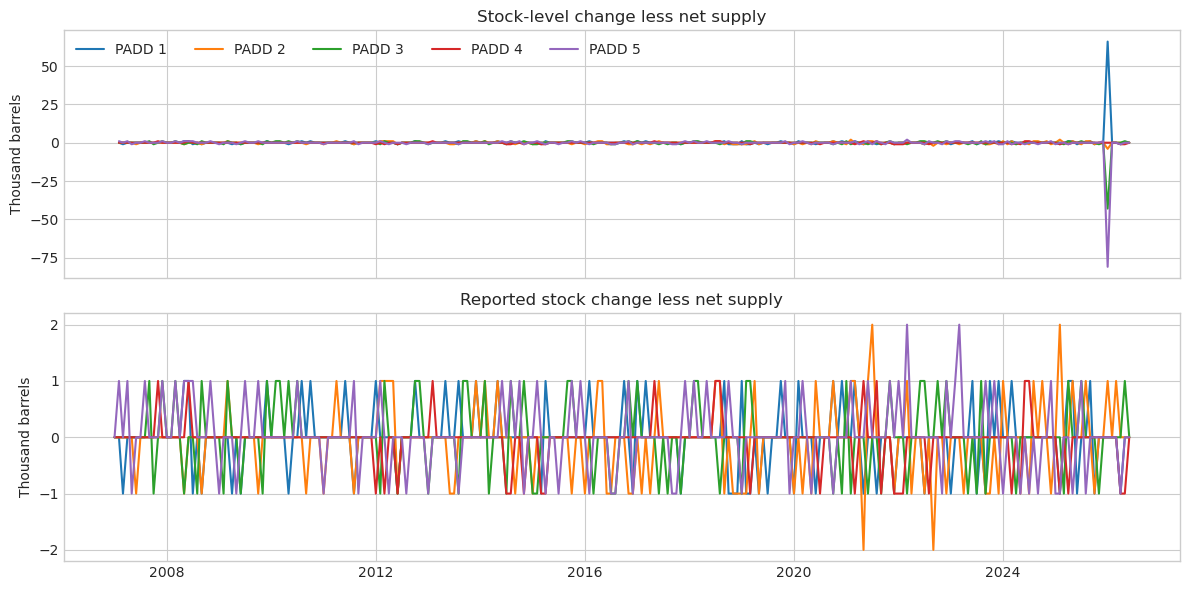

In [7]:
# Audit stock-level change against published stock change and net supply.
# Their residual decomposition is checked algebraically, allowing first-month
# NaNs. The >5 kb threshold selects displayed exceptions, not training exclusions.

checks = panel.groupby('padd').agg(
    maximum_balance_residual_kb=('accounting_residual_kb', lambda s: s.abs().max()),
    maximum_reported_change_difference_kb=('reported_change_residual_kb', lambda s: s.abs().max()),
    maximum_flow_reporting_residual_kb=('flow_reporting_residual_kb', lambda s: s.abs().max()))
display(checks.rename(columns={
    'maximum_balance_residual_kb':'Max stock-level change less net supply (kb)',
    'maximum_reported_change_difference_kb':'Max stock-level change less reported change (kb)',
    'maximum_flow_reporting_residual_kb':'Max reported change less net supply (kb)'}))
# Verify the two diagnostic residuals add to the total mismatch; initial
# NaNs are expected because the first stock observation has no predecessor.
np.testing.assert_allclose(panel.accounting_residual_kb,
    panel.reported_change_residual_kb + panel.flow_reporting_residual_kb, equal_nan=True)
exceptions = panel[panel.accounting_residual_kb.abs()>5].copy()
# Express each exception relative to inventory size and as a daily equivalent
# so its practical scale can be assessed alongside the monthly kb difference.
exceptions['difference_pct_of_stocks'] = 100*exceptions.accounting_residual_kb/exceptions.stock_kb
exceptions['difference_kbd'] = exceptions.accounting_residual_kb/exceptions.month.dt.days_in_month
display(exceptions[['month','padd','previous_stock_kb','stock_kb','stock_change_kb',
    'reported_stock_change_kb','balance_kb','accounting_residual_kb',
    'flow_reporting_residual_kb','difference_pct_of_stocks','difference_kbd']])
exceptions.to_csv(OUTPUT/'historical_balance_exceptions.csv', index=False)
fig, axes = plt.subplots(2,1,figsize=(12,6),sharex=True)
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month,g.accounting_residual_kb,label=f'PADD {p}')
    axes[1].plot(g.month,g.flow_reporting_residual_kb,label=f'PADD {p}')
axes[0].set(title='Stock-level change less net supply',ylabel='Thousand barrels')
axes[1].set(title='Reported stock change less net supply',ylabel='Thousand barrels')
axes[0].legend(ncol=5); plt.tight_layout(); plt.show()


### Balance reconciliation

In January 2026, stock-level changes differ from reported stock changes by +66, −43, and −81 thousand barrels in PADDs 1, 3, and 5.

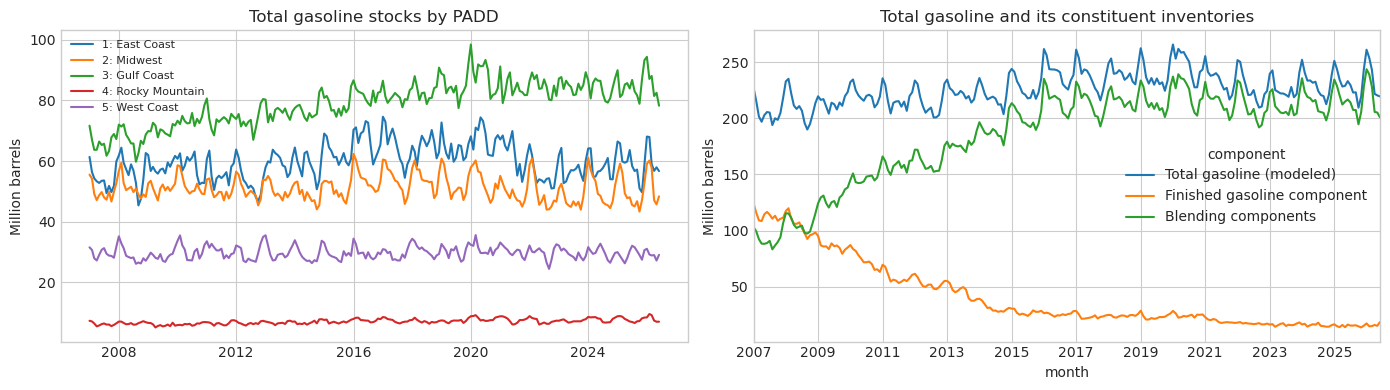

In [8]:
# Compare regional total stocks and the national finished/blending components.
# The modeled target is total gasoline, not finished gasoline alone; /1000
# converts stored thousand barrels into million barrels for plotting.

fig, axes = plt.subplots(1,2,figsize=(14,4))
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month, g.stock_kb/1000, label=f'{p}: {PADD_NAMES[p]}')
context = panel.groupby('month')[['stock_kb','finished_stock_kb','blending_stock_kb']].sum()
(context/1000).rename(columns={'stock_kb':'Total gasoline (modeled)',
    'finished_stock_kb':'Finished gasoline component', 'blending_stock_kb':'Blending components'}).plot(ax=axes[1])
axes[0].set_title('Total gasoline stocks by PADD'); axes[0].legend(fontsize=8)
axes[1].set_title('Total gasoline and its constituent inventories')
for ax in axes: ax.set_ylabel('Million barrels')
plt.tight_layout(); plt.show()

### Forecast inputs

Predict month-end stocks using prior stocks, stock changes, flows, and seasonal patterns. 

Forecast flows using trends and calendar-month effects.

In [9]:
# Build a trend in years plus 11 calendar-month indicators. January is the
# reference month represented by the regression intercept.
def seasonal_design(months, origin):
    dates = pd.DatetimeIndex(months)
    trend = ((dates.year - origin.year) * 12 + dates.month - origin.month).to_numpy() / 12
    return np.column_stack([trend] + [(dates.month == m).astype(float) for m in range(2, 13)])


# Use only the supplied origin history. The last 60 non-COVID observations may
# span more than 60 calendar months because excluded months are skipped.
def forecast_flows(history, months):
    """Fit monthly daily-rate seasonality + trend on the last 60 observed months."""
    train = history.loc[outside_covid(history.month)].tail(60)
    model = LinearRegression()
    # Fit gasoline flows as daily rates, preventing longer months from appearing
    # artificially stronger. [:, None] broadcasts one day-count divisor across each row.
    model.fit(seasonal_design(train.month, train.month.iloc[0]),
              train[FLOWS].to_numpy() / train.month.dt.days_in_month.to_numpy()[:, None])
    rates = model.predict(seasonal_design(months, train.month.iloc[0]))
    # Convert forecast daily rates back to monthly volumes using target-month day
    # counts, including February and leap years.
    flows = rates * pd.DatetimeIndex(months).days_in_month.to_numpy()[:, None]
    for c in ['demand_kb', 'imports_kb', 'exports_kb']:
        flows[:, FLOWS.index(c)] = np.maximum(flows[:, FLOWS.index(c)], 0)
    # Net refinery production, receipts, adjustments and biofuel net production can be negative.
    return pd.DataFrame(flows, columns=FLOWS, index=pd.DatetimeIndex(months))

In [10]:
# Build target-month inputs from history ending one month earlier. History must
# be sorted, continuous, and contain at least 12 monthly observations.
def feature_row(history, month):
    last = history.iloc[-1]
    # Use prior stock, year-ago stock, and the latest stock change. Sine/cosine encode
    # annual seasonality smoothly across the December/January boundary.
    row = {'stock_lag1': last.stock_kb, 'stock_lag12': history.iloc[-12].stock_kb,
           'change_lag1': last.stock_kb - history.iloc[-2].stock_kb,
           'sin_month': np.sin(2*np.pi*month.month/12), 'cos_month': np.cos(2*np.pi*month.month/12)}
    # Calculate observed changes before filtering; omit any change whose current
    # or previous stock observation falls inside the excluded COVID period.
    changes = history.set_index('month').stock_kb.diff()
    clean = outside_covid(changes.index) & outside_covid(changes.index - pd.DateOffset(months=1))
    changes = changes.loc[clean].tail(60)
    # Average recent eligible changes for the target calendar month; use zero
    # if that month has no usable historical changes.
    seasonal = changes[changes.index.month == month.month].dropna()
    row['seasonal_change'] = float(seasonal.mean()) if len(seasonal) else 0.0
    # Compare the latest stock with earlier same-calendar-month stock levels,
    # excluding the latest observation from its own reference average.
    normal_history = history.iloc[:-1].loc[lambda f: outside_covid(f.month)].tail(60)
    normal = normal_history[normal_history.month.dt.month.eq(last.month.month)].stock_kb
    row['stock_seasonal_gap'] = float(last.stock_kb - normal.mean()) if len(normal) else 0.0
    # Pre-sign prior-month flows so nonnegative regression coefficients retain the
    # supply-versus-demand direction in the constrained model.
    row.update({'lag_' + c: last[c] * sign for c, sign in zip(FLOWS, SIGNS)})
    return row


# Create labeled rows after a 12-month warm-up. Rebuild each feature vector and
# flow-identity benchmark using only history preceding that row's target month.
def supervised(history):
    rows = []
    for i in range(12, len(history)):
        # Keep the target separate: its stock supplies actual_kb/delta_kb only. Actual
        # target-month flows must not become inputs to a prediction of that month.
        past, current = history.iloc[:i], history.iloc[i]
        row = feature_row(past, current.month)
        flow = forecast_flows(past, [current.month]).iloc[0]
        row.update(month=current.month, origin_month=past.month.iloc[-1],
                   actual_kb=current.stock_kb, delta_kb=current.stock_kb-past.stock_kb.iloc[-1],
                   forecast_flow_identity=max(0.0, past.stock_kb.iloc[-1] + flow.to_numpy() @ SIGNS))
        rows.append(row)
    return pd.DataFrame(rows)

In [11]:
# Inspect a few supervised rows to make the forecast origin/target alignment
# concrete. Each origin must precede its target; actual_kb is an outcome only.

example = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
display(example[['origin_month','month','stock_lag1','stock_lag12','lag_production_kb',
                 'forecast_flow_identity','actual_kb']].tail(5))
assert (example.origin_month < example.month).all()
# Notice: actual_kb is the outcome, never a feature passed to a fitted estimator.

,origin_month,month,stock_lag1,stock_lag12,lag_production_kb,forecast_flow_identity,actual_kb
217,2026-01-01,2026-02-01,"68,046.00","65,816.00","22,814.00","67,817.66","67,907.00"
218,2026-02-01,2026-03-01,"67,907.00","59,836.00","20,737.00","60,730.14","59,053.00"
219,2026-03-01,2026-04-01,"59,053.00","59,440.00","23,537.00","58,491.03","56,752.00"
220,2026-04-01,2026-05-01,"56,752.00","59,838.00","22,717.00","58,933.75","57,919.00"
221,2026-05-01,2026-06-01,"57,919.00","63,611.00","22,503.00","60,201.20","56,678.00"


### Tested models

Compare unchanged stocks, prior-year stocks, seasonal changes, flow balance, regression variants, random forest, XGBoost, and a neural network. The definitions below specify inputs and settings.

In [12]:
# Baselines carry stocks forward, repeat year-ago stocks, add a seasonal change,
# or accumulate forecast net flows; none needs a fitted stock estimator.
BASELINES = ['persistence', 'seasonal_naive', 'seasonal_change', 'forecast_flow_identity']
# Candidates share forecast timing and evaluation. Names ending in '_change'
# model stock increments, while constrained_level models inventory levels.
LEARNED = ['constrained_level', 'ridge_change', 'seasonal_ridge_change',
           'polynomial_ridge_change', 'spline_ridge_change', 'random_forest_change',
           'xgboost_change', 'neural_network_change']
LEARNED += ['seasonal_residual_change', 'huber_change']
MODELS = BASELINES + LEARNED
BASE_FEATURES = ['stock_lag1', 'stock_lag12', 'change_lag1'] + ['lag_' + c for c in FLOWS]
FEATURES = BASE_FEATURES + ['sin_month', 'cos_month']

In [13]:
# Select predictor columns explicitly. actual_kb and delta_kb are labels and
# must never enter the estimator's input matrix.
def columns(name):
    if name == 'seasonal_residual_change':
        return FEATURES + ['stock_seasonal_gap', 'seasonal_change']
    if name == 'constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS]
    if name == 'ridge_change':
        return BASE_FEATURES
    return FEATURES


# Return an unfitted candidate. Pipeline transformations are learned inside each
# fit, so test observations cannot influence scaling or spline preparation.
def estimator(name):
    if name == 'seasonal_residual_change':
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'huber_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Huber loss reduces outlier influence; the surrounding target transformer
            # scales the response and reverses that scaling when predicting.
            HuberRegressor(max_iter=1000)), transformer=StandardScaler())
    if name == 'constrained_level':
        # Constrain coefficients, not the intercept, to be nonnegative. Pre-signed demand
        # features therefore contribute negatively without imposing a full flow identity.
        return LinearRegression(positive=True)
    if name in ['ridge_change', 'seasonal_ridge_change']:
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'polynomial_ridge_change':
        # Expand predictors with powers/interactions, rescale, and regularize to control
        # flexibility. The regression supplies the intercept, so no bias column is needed.
        return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                             StandardScaler(), Ridge(alpha=1000))
    if name == 'spline_ridge_change':
        # Represent each feature using smooth piecewise-polynomial basis functions;
        # linear extrapolation controls behavior outside its observed training range.
        return make_pipeline(SplineTransformer(n_knots=4, degree=2, extrapolation='linear'),
                             StandardScaler(), Ridge(alpha=100))
    if name == 'random_forest_change':
        # Average resampled decision trees. Depth and minimum leaf size limit complexity;
        # the fixed seed makes randomized fitting reproducible.
        return RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12,
                                     max_features=0.8, n_jobs=1, random_state=42)
    if name == 'xgboost_change':
        # Boost shallow trees sequentially. Learning rate, regularization, and row/column
        # subsampling control how aggressively the ensemble fits remaining residuals.
        return XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03,
            min_child_weight=12, reg_lambda=30, subsample=0.8, colsample_bytree=0.8,
            n_jobs=1, random_state=42, objective='reg:squarederror')
    if name == 'neural_network_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Fit a small neural network with LBFGS on scaled inputs and a scaled target.
            # Alpha penalizes weights, and the random seed fixes initialization.
            MLPRegressor(hidden_layer_sizes=(16,), alpha=10, solver='lbfgs',
                         max_iter=3000, random_state=42)), transformer=StandardScaler())
    raise ValueError(name)

In [14]:
# Return (estimator, warning_text). Baselines return None because predict computes
# them directly; learned candidates filter training dates before fitting.
def fit(name, train, params=None):
    if name in BASELINES:
        return None, ''
    train = training_rows(train)
    model = estimator(name)
    if params:
        model.set_params(**params)
    # Choose inventory level or monthly change as response, both in thousand barrels.
    target = 'actual_kb' if name == 'constrained_level' else 'delta_kb'
    # Match the search's numerical settings, including neural-network refits.
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1):
        warnings.simplefilter('always', ConvergenceWarning)
        # Fit the seasonal-residual candidate to departures from normal seasonal change;
        # predict reconstructs the seasonal component before converting to stock levels.
        values = train[target] - train.seasonal_change if name == 'seasonal_residual_change' else train[target]
        model.fit(train[columns(name)], values)
    return model, '; '.join(str(w.message) for w in caught)


# Return stock levels in kb for every candidate, including change-based models.
# Use identical reconstruction and flooring rules during tuning and forecasting.
def predict(name, model, frame):
    if name == 'persistence':
        return frame.stock_lag1.to_numpy()
    if name == 'seasonal_naive':
        return frame.stock_lag12.to_numpy()
    if name == 'seasonal_change':
        return np.maximum(0, frame.stock_lag1.to_numpy() + frame.seasonal_change.to_numpy())
    if name == 'forecast_flow_identity':
        return frame.forecast_flow_identity.to_numpy()
    prediction = model.predict(frame[columns(name)])
    if name == 'seasonal_residual_change':
        prediction += frame.seasonal_change.to_numpy()
    # Add the predicted increment to prior stock to recover an inventory level.
    if name != 'constrained_level':
        prediction += frame.stock_lag1.to_numpy()
    # Prevent a learned model from producing a negative final stock level.
    return np.maximum(prediction, 0)

In [15]:
# Enumerate tunable combinations. Double underscores address nested pipeline
# parameters; an empty grid indicates a candidate with no parameter search.
def parameter_grid(name):
    """Conventional compact grids for each tunable model family."""
    if name == 'seasonal_residual_change':
        return {'ridge__alpha': [0.1, 1, 10, 100, 1000]}
    if name == 'huber_change':
        return {'regressor__huberregressor__epsilon': [1.35, 1.75],
                'regressor__huberregressor__alpha': [0.01, 1, 10]}
    if name in ['ridge_change', 'seasonal_ridge_change']:
        return {'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    if name == 'polynomial_ridge_change':
        return {'polynomialfeatures__degree': [1, 2], 'ridge__alpha': [1, 10, 100, 1000]}
    if name == 'spline_ridge_change':
        return {'splinetransformer__n_knots': [3, 5, 7],
                'splinetransformer__degree': [2, 3], 'ridge__alpha': [1, 100, 1000]}
    if name == 'random_forest_change':
        return {'n_estimators': [100, 200], 'max_depth': [3, 5, None],
                'min_samples_leaf': [5, 12]}
    if name == 'xgboost_change':
        return {'n_estimators': [100, 200], 'max_depth': [2, 4],
                'learning_rate': [0.01, 0.05, 0.1], 'reg_lambda': [1, 30]}
    if name == 'neural_network_change':
        return {'regressor__mlpregressor__hidden_layer_sizes': [(16,), (32,), (32, 16)],
                'regressor__mlpregressor__alpha': [0.01, 1, 10]}
    return {}


# Adapt candidates to sklearn's cloning/search interface. Score reconstructed
# stock levels, including seasonal adjustments, damping, and the zero floor.
class StockRegressor(RegressorMixin, BaseEstimator):
    """Let GridSearchCV score the final stock-level forecast."""
    def __init__(self, name, model):
        self.name = name
        self.model = model

    def fit(self, X, y):
        from sklearn.base import clone
        X = training_rows(X)
        target = X.actual_kb if self.name == 'constrained_level' else X.delta_kb
        if self.name == 'seasonal_residual_change':
            target = target - X.seasonal_change
        # Clone an unfitted candidate for each fold so fitted state cannot leak across
        # search trials. A trailing underscore conventionally marks fitted attributes.
        self.model_ = clone(self.model).fit(X[columns(self.name)], target)
        return self

    def predict(self, X):
        return predict(self.name, self.model_, X)


# Search only the supplied past window; return parameters, all candidate/fold
# scores, and convergence warnings. The chosen estimator is fitted separately.
def tune(name, train, folds=10, jobs=8, splits=None):
    """Search past-only folds and retain every candidate's scores."""
    grid = parameter_grid(name)
    if not grid:
        return {}, pd.DataFrame(), ''
    cv = splits if splits is not None else validation_splits(train, folds)
    # Maximize negative MAE, equivalent to minimizing stock error. model__ reaches
    # the candidate inside StockRegressor; refit=False avoids an unused final fit.
    search = GridSearchCV(StockRegressor(name, estimator(name)),
        {'model__' + key: value for key, value in grid.items()},
        scoring='neg_mean_absolute_error', cv=cv, n_jobs=jobs,
        refit=False, error_score='raise', return_train_score=True)
    from joblib import parallel_backend
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1), parallel_backend('threading'):
        warnings.simplefilter('always', ConvergenceWarning)
        search.fit(train, train.actual_kb)
    results = pd.DataFrame(search.cv_results_)
    results['params'] = results.params.map(
        lambda p: json.dumps({k.removeprefix('model__'): v for k,v in p.items()}, sort_keys=True))
    # Reverse sklearn's negative-score convention to report positive MAE.
    results['mean_test_mae_kb'] = -results.mean_test_score
    # Remove the wrapper prefix so fit() can set parameters on the candidate itself.
    params = {k.removeprefix('model__'): v for k,v in search.best_params_.items()}
    warning = '; '.join(sorted({str(w.message) for w in caught}))
    return params, results, warning

In [16]:
# Show each candidate's search space before running the experiment; nested
# parameter names identify the relevant estimator or pipeline transformation.

display(pd.DataFrame([{'model':name,'param_grid':parameter_grid(name)} for name in LEARNED]))

,model,param_grid
0,constrained_level,{}
1,ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
2,seasonal_ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
3,polynomial_ridge_change,"{'polynomialfeatures__degree': [1, 2], 'ridge_..."
4,spline_ridge_change,"{'splinetransformer__n_knots': [3, 5, 7], 'spl..."
5,random_forest_change,"{'n_estimators': [100, 200], 'max_depth': [3, ..."
6,xgboost_change,"{'n_estimators': [100, 200], 'max_depth': [2, ..."
7,neural_network_change,{'regressor__mlpregressor__hidden_layer_sizes'...
8,seasonal_residual_change,"{'ridge__alpha': [0.1, 1, 10, 100, 1000]}"
9,huber_change,"{'regressor__huberregressor__epsilon': [1.35, ..."


In [17]:
# MAE and RMSE are in kb; RMSE weights large misses more. R-squared is unitless
# and may be negative when errors exceed the actual sample's mean-only benchmark.
def score(actual, predicted):
    return {'mae_kb': mean_absolute_error(actual, predicted),
            'rmse_kb': mean_squared_error(actual, predicted)**0.5,
            'r2': r2_score(actual, predicted), 'n': len(actual)}


# Require one row for every PADD in each group before summing additive columns.
# Compute national errors after summation; regional forecast errors can offset.
def aggregate(frame, keys, additive):
    """Reject partial U.S. totals instead of silently summing fewer than five PADDs."""
    if frame.duplicated(keys + ['padd']).any():
        raise ValueError('Duplicate PADD rows in aggregation')
    if not frame.groupby(keys).padd.nunique().eq(5).all():
        raise ValueError('U.S. aggregation requires all five PADDs')
    return frame.groupby(keys, as_index=False)[additive].sum(min_count=5)


# Score each group, expanding either a scalar or tuple group key into the named
# key columns of the resulting metrics table.
def metric_table(predictions, keys):
    return pd.DataFrame([{**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
        **score(g.actual_kb, g.predicted_kb)} for k,g in predictions.groupby(keys)])

## Training

Select models with the lowest development MAE.

In [18]:
# Work through the first expanding-window fold for one PADD with the constrained
# model. This illustrative split uses the raw calendar; the full evaluation
# uses validation_splits for COVID-eligible target dates. fit still filters inputs.

worked = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
development_example = worked.iloc[:-24]
train_idx, test_idx = next(TimeSeriesSplit(n_splits=10, test_size=12).split(development_example))
train_example, test_example = development_example.iloc[train_idx], development_example.iloc[test_idx]
example_model, example_warning = fit('constrained_level', train_example)
example_predictions = predict('constrained_level', example_model, test_example)
worked_results = test_example[['origin_month','month','actual_kb']].copy()
worked_results['predicted_kb'] = example_predictions
worked_results['absolute_error_kb'] = abs(worked_results.actual_kb-worked_results.predicted_kb)
print('Training targets:',train_example.month.min().date(),'to',train_example.month.max().date())
display(worked_results)
display(pd.Series(score(test_example.actual_kb,example_predictions),name='Worked-fold scores'))
assert train_example.month.max() < test_example.month.min()

Training targets: 2008-01-01 to 2014-06-01


,origin_month,month,actual_kb,predicted_kb,absolute_error_kb
78,2014-06-01,2014-07-01,"59,765.00","60,048.29",283.29
79,2014-07-01,2014-08-01,"57,773.00","58,116.20",343.20
80,2014-08-01,2014-09-01,"55,712.00","57,668.53","1,956.53"
81,2014-09-01,2014-10-01,"50,685.00","55,592.71","4,907.71"
82,2014-10-01,2014-11-01,"53,624.00","51,854.05","1,769.95"
83,2014-11-01,2014-12-01,"62,085.00","57,592.70","4,492.30"
84,2014-12-01,2015-01-01,"69,032.00","63,100.06","5,931.94"
85,2015-01-01,2015-02-01,"68,142.00","66,421.36","1,720.64"
86,2015-02-01,2015-03-01,"64,542.00","61,938.98","2,603.02"
87,2015-03-01,2015-04-01,"63,272.00","61,243.42","2,028.58"


mae_kb    2,447.15
rmse_kb   2,979.55
r2            0.68
n            12.00
Name: Worked-fold scores, dtype: float64

In [19]:
# Inspect estimator definitions and feature columns before fitting. Printed
# objects describe configuration, not learned coefficients or held-out accuracy.

# Inspect any candidate and its exact feature list without opening another notebook.
print('XGBoost features:', columns('xgboost_change'))
print(estimator('xgboost_change'))
print(estimator('neural_network_change'))

XGBoost features: ['stock_lag1', 'stock_lag12', 'change_lag1', 'lag_production_kb', 'lag_demand_kb', 'lag_imports_kb', 'lag_exports_kb', 'lag_net_receipts_kb', 'lag_adjustments_kb', 'lag_biofuels_kb', 'sin_month', 'cos_month']
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=1, num_parallel_tree=None, ...)
TransformedTargetRegressor(regress

### Model selection

- **One month:** Compare methods on ten chronological development tests, then sum PADD forecasts. The current outlook uses `seasonal_change`, which has the lowest U.S. MAE in July 2024–June 2026.
- **Twelve months:** Select a development candidate on six annual paths, then compare it with simple benchmarks on two final-period annual paths. Use the method with the lowest national MAE for the current outlook. Predicted stocks feed later months without actual-data updates.

Exclude March 2020–March 2021 and stock-training rows that use those months as inputs. The stock-training exclusions extend through March 2022.

Tests use revised EIA data and assume prior-month observations are available. The final 24 months were used to choose the current one-month and twelve-month methods, so their reported errors are retrospective comparisons. It is not an untouched test of that choice.

Refit the chosen models on all eligible observations for the outlook.


In [20]:
# Choose each PADD's one-step candidate on development data, evaluate the fixed
# choices on the last 24 months, then refit winners for the live outlook.
def evaluate(samples, folds=10, holdout=24, jobs=8):
    """Choose models only on development CV; score untouched final 24 months."""
    predictions, fold_metrics, selections, fitted, warning_rows = [], [], [], {}, []
    best_parameters, searches = {}, []
    for padd, frame in samples.items():
        # Reserve the final holdout rows before any tuning or candidate selection.
        development = frame.iloc[:-holdout]
        if len(development) - folds*12 < 36:
            raise ValueError('Need >=36 initial training months plus 10 annual folds and holdout')
        splits = validation_splits(development, folds, test_size=12)
        for name in MODELS:
            params, results, warning = tune(name, development, folds, jobs, splits)
            best_parameters[padd, name] = params
            if not results.empty:
                searches.append(results.assign(padd=padd, model=name, stage='development',
                    train_end=development.month.max()))
                print(f'PADD {padd} {name}: grid MAE {results.mean_test_mae_kb.min():,.1f}; {params}', flush=True)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='grid_search', warning=warning))
            # Reuse tuning folds for development diagnostics; these are selection scores,
            # not independent nested-CV estimates of future generalization.
            for fold, (tr, te) in enumerate(splits, 1):
                train, test = training_rows(development.iloc[tr]), development.iloc[te]
                model, warning = fit(name, train, params)
                pred = predict(name, model, test)
                fold_metrics.append(dict(padd=padd, model=name, fold=fold,
                    train_end=train.month.max(), test_start=test.month.min(), test_end=test.month.max(),
                    train_mae_kb=mean_absolute_error(train.actual_kb, predict(name, model, train)),
                    **score(test.actual_kb, pred)))
                output = test[['month', 'origin_month', 'actual_kb']].copy()
                output['predicted_kb'], output['padd'], output['model'] = pred, padd, name
                output['split'], output['fold'] = 'cv', fold
                predictions.append(output)
                if warning:
                    warning_rows.append(dict(padd=padd, model=name, stage=f'cv_{fold}', warning=warning))
        current = pd.concat(predictions, ignore_index=True)
        current = current[current.padd.eq(padd)]
        # Pool absolute development errors for this PADD across folds and select
        # the lowest mean; no holdout observations enter this comparison.
        losses = current.assign(error=lambda x: abs(x.actual_kb-x.predicted_kb)).groupby('model').error.mean()
        winner = losses.idxmin()
        selections.append(dict(padd=padd, selected_model=winner, cv_mae_kb=losses[winner]))
        for name in MODELS:
            model, warning = fit(name, development, best_parameters[padd, name])
            # This is one-step evaluation: each row uses actual prior-month inputs, while
            # estimator parameters remain fitted on development data for the entire block.
            test = frame.iloc[-holdout:]
            output = test[['month', 'origin_month', 'actual_kb']].copy()
            output['predicted_kb'] = predict(name, model, test)
            output['padd'], output['model'], output['split'], output['fold'] = padd, name, 'holdout', 0
            predictions.append(output)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='holdout', warning=warning))
        # Refit the already chosen winner on all eligible history for future use.
        # This final estimator is separate from the one that produced holdout scores.
        final, warning = fit(winner, frame, best_parameters[padd, winner])
        fitted[padd] = {'name': winner, 'estimator': final}
        if warning:
            warning_rows.append(dict(padd=padd, model=winner, stage='final', warning=warning))
        print(f'PADD {padd}: selected {winner}; CV MAE {losses[winner]:,.1f} kb', flush=True)
    return (pd.concat(predictions, ignore_index=True), pd.DataFrame(fold_metrics),
            pd.DataFrame(selections), fitted,
            pd.DataFrame(warning_rows, columns=['padd','model','stage','warning']),
            best_parameters, pd.concat(searches, ignore_index=True))

Annual forecasts carry predicted stocks and flows forward one month at a time. Report the difference between the flow balance and statistical stock path separately.

In [21]:
# Produce a recursive path per district plus national sums. After the origin,
# features depend on predicted stocks/flows, not future actual observations.
def forecast(history, fitted, horizon=12):
    all_paths = []
    for p, state in fitted.items():
        past = history[history.padd.eq(p)].sort_values('month').copy()
        origin = past.month.iloc[-1]
        months = pd.date_range(origin + pd.offsets.MonthBegin(), periods=horizon, freq='MS')
        # Forecast the full flow path once at the origin; do not refit flows each step
        # using synthetic observations appended to the stock path.
        flows = forecast_flows(past, months)
        # Track a separate raw flow-identity path initialized at the last observed stock.
        identity_stock = past.stock_kb.iloc[-1]
        for h, month in enumerate(months, 1):
            previous = past.stock_kb.iloc[-1]
            flow = flows.loc[month]
            balance = flow.to_numpy() @ SIGNS
            # At longer horizons, past contains earlier predicted rows. This is the recursive
            # feedback through which forecast errors can propagate along the path.
            features = feature_row(past, month)
            features['forecast_flow_identity'] = max(0.0, previous + balance)
            stock = float(predict(state['name'], state['estimator'], pd.DataFrame([features]))[0])
            # Keep the raw flow accumulation unclipped so impossible inventory paths remain
            # visible; it can diverge from the statistical stock forecast.
            identity_stock += balance
            row = dict(month=month, origin_month=origin, horizon=h, padd=p,
                padd_name=PADD_NAMES[p], model=state['name'], stock_kb=stock,
                previous_stock_kb=previous, stock_change_kb=stock-previous,
                identity_stock_unclipped_kb=identity_stock, balance_kb=balance,
                # Report statistical stock change minus monthly net supply in kb; this
                # discrepancy is not an extra observed EIA adjustment.
                model_reconciliation_kb=stock-previous-balance,
                supply_kb=flow.production_kb+flow.imports_kb+flow.net_receipts_kb+flow.adjustments_kb+flow.biofuels_kb,
                total_demand_kb=flow.demand_kb+flow.exports_kb, **flow.to_dict())
            all_paths.append(row)
            # Append the predicted row so the next month uses this stock and these flows
            # as its most recent history, without seeing future actual values.
            past = pd.concat([past, pd.DataFrame([row])], ignore_index=True)
    regional = pd.DataFrame(all_paths)
    sums = FLOWS + ['stock_kb', 'previous_stock_kb','stock_change_kb', 'identity_stock_unclipped_kb',
                   'balance_kb','model_reconciliation_kb','supply_kb','total_demand_kb']
    return regional, aggregate(regional, ['month','origin_month','horizon'], sums)


# Select the year-ahead family separately from one-step winners, using complete
# recursive development paths and their national stock errors.
def select_horizon(samples, panel, folds=10, jobs=8):
    """Select a year-ahead model using full forecast paths on earlier non-COVID years."""
    predictions, searches, warning_rows = [], [], []
    development_end = samples[1].month.iloc[-25]
    for cutoff in recursive_origins(development_end):
        for name in MODELS:
            states = {}
            for p in PADD_NAMES:
                # Restrict fitting to targets observed by this simulated forecast origin.
                train = samples[p][samples[p].month.le(cutoff)]
                # Retune using only this origin's past history before generating its full path.
                params, results, warning = tune(name, train, folds, jobs)
                if not results.empty:
                    searches.append(results.assign(padd=p, model=name,
                        stage='recursive_development', train_end=cutoff))
                if warning:
                    warning_rows.append(dict(padd=p, model=name, stage='recursive_grid_search', warning=warning))
                model, warning = fit(name, train, params)
                if warning:
                    warning_rows.append(dict(padd=p, model=name, stage='recursive_cv', warning=warning))
                states[p] = {'name':name, 'estimator':model}
            path, _ = forecast(panel[panel.month.le(cutoff)], states)
            path = path[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
            # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
            # duplicate month/PADD observations that could otherwise multiply rows.
            path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
            predictions.append(path.assign(model=name))
        print(f'Recursive development origin {cutoff.date()} complete', flush=True)
    predictions = pd.concat(predictions, ignore_index=True)
    national = aggregate(predictions, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
    # Compare national error across complete development paths to select one common
    # family for all PADDs; individual regional estimators are still fitted separately.
    scores = metric_table(national, ['model']).sort_values(['mae_kb','model'])
    return scores.iloc[0].model, predictions, national, scores, pd.concat(searches, ignore_index=True), pd.DataFrame(warning_rows)

In [22]:
# Run controls: use ten expanding validation folds and eight search workers.
# The worker count controls parallel grid trials; numerical threads are capped
# inside fitting to avoid multiplying the number of active CPU threads.

data_dir=HERE/'data'
output_dir=OUTPUT
folds=10
jobs=8

### Fit and evaluate

Prepare regional training data, compare candidates, and evaluate selected models on the final 24 months.

In [ ]:
output = Path(output_dir)
# Build chronological supervised samples separately for all five districts,
# then run the full development search, one-step holdout evaluation, and refits.
# This is a computationally expensive cell; progress and warnings are retained.
output.mkdir(parents=True, exist_ok=True)
panel = load_panel(data_dir)
histories = {p: panel[panel.padd.eq(p)].reset_index(drop=True) for p in PADD_NAMES}
samples = {p: supervised(history) for p,history in histories.items()}
predictions, fold_metrics, selection, fitted, fit_warnings, best_parameters, grid_results = evaluate(samples, folds, jobs=jobs)

display(fold_metrics.groupby('model').agg(folds=('fold','count'),test_mae_kb=('mae_kb','mean')))
display(selection)

In [ ]:
# Assemble the one-step regional-winner model and score national sums. Select
# the year-ahead family separately on recursive development paths, then refit
# that family for each region to generate the 12-month outlook.

# Label the development-selected regional forecasts as a combined model while
# retaining every original candidate's predictions for comparison.
selected = predictions.merge(selection[['padd','selected_model']], on='padd')
selected = selected[selected.model.eq(selected.selected_model)].copy()
selected['model'] = 'selected_padd_models'
one_month_models = selection.sort_values('padd').set_index('padd').selected_model.to_dict()
one_month_model_label = ' + '.join(dict.fromkeys(one_month_models.values()))
combined = pd.concat([predictions, selected[predictions.columns]], ignore_index=True)
us_predictions = aggregate(combined, ['month','origin_month','model','split','fold'], ['actual_kb','predicted_kb'])
padd_metrics = metric_table(combined, ['padd','model','split'])
us_metrics = metric_table(us_predictions, ['model','split'])
# Use the lowest national final-period MAE for the current one-month outlook.
# This makes the final period a selection sample for this deployed choice.
one_month_model = (us_metrics[us_metrics.split.eq('holdout')]
    .sort_values(['mae_kb','model']).iloc[0].model)
if one_month_model != 'selected_padd_models':
    one_month_models = {p: one_month_model for p in PADD_NAMES}
    one_month_model_label = one_month_model
    fitted = {}
    for p, frame in samples.items():
        model, warning = fit(one_month_model, frame, best_parameters[p, one_month_model])
        fitted[p] = {'name':one_month_model, 'estimator':model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, one_month_model, 'one_month_final', warning]
# Generate the next month using the selected one-step estimators. The separate
# year-ahead selection below may choose a different family for the 12-month path.
one_step_regional, one_step_national = forecast(panel, fitted, horizon=1)
development_year_ahead_model, recursive_cv, us_recursive_cv, horizon_scores, horizon_grids, horizon_warnings = select_horizon(samples, panel, folds, jobs)
grid_results = pd.concat([grid_results, horizon_grids], ignore_index=True)
fit_warnings = pd.concat([fit_warnings, horizon_warnings], ignore_index=True)
# Refit the selected year-ahead family on full eligible history, using parameter
# settings chosen before the holdout; then build the forward 12-month outlook.
horizon_fitted = {}
for p, frame in samples.items():
    model, warning = fit(development_year_ahead_model, frame, best_parameters[p, development_year_ahead_model])
    horizon_fitted[p] = {'name':development_year_ahead_model, 'estimator':model}
    if warning:
        fit_warnings.loc[len(fit_warnings)] = [p, development_year_ahead_model, 'horizon_final', warning]

display(us_metrics.sort_values(['split','mae_kb']))

Test the selected year-ahead method on two separate annual paths against unchanged stocks and the one-month models rolled forward.

In [ ]:
# Test two nonoverlapping 12-month paths in the holdout using the same recursion
# as the outlook. Refit at each origin with fixed development-selected settings,
# and compare with persistence and the recursively applied one-step model.

# Two disjoint 12-month paths in the final holdout: same recursive procedure as outlook.
recursive = []
recursive_benchmarks = []
# Use the two annual blocks within the final 24 months, starting 24 and
# 12 months before the final observed date.
for offset in [24, 12]:
    states = {}
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    for p, state in horizon_fitted.items():
        # Restrict fitting to targets observed by this simulated forecast origin.
        train = samples[p][samples[p].month.le(cutoff)]
        model, warning = fit(state['name'], train, best_parameters[p, state['name']])
        states[p] = {'name': state['name'], 'estimator': model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, state['name'], 'recursive_holdout', warning]
    path, _ = forecast(panel[panel.month.le(cutoff)], states)
    # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
    # duplicate month/PADD observations that could otherwise multiply rows.
    path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], suffixes=('_forecast','_actual'), validate='one_to_one')
    path = path.rename(columns={'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'})
    recursive.append(path)
    for label in dict.fromkeys(['persistence', one_month_model_label, 'seasonal_naive']):
        baseline_states = {}
        for p in PADD_NAMES:
            name = label if label in ('persistence', 'seasonal_naive') else one_month_models[p]
            model, warning = fit(name, samples[p][samples[p].month.le(cutoff)], best_parameters[p, name])
            baseline_states[p] = {'name':name, 'estimator':model}
        baseline, _ = forecast(panel[panel.month.le(cutoff)], baseline_states)
        baseline = baseline[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
        baseline = baseline.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
        recursive_benchmarks.append(baseline.assign(model=label))
recursive = pd.concat(recursive, ignore_index=True)
recursive_benchmarks.append(recursive[['padd','month','origin_month','horizon','actual_kb','predicted_kb']]
    .assign(model=development_year_ahead_model))
recursive_benchmarks = pd.concat(recursive_benchmarks, ignore_index=True)
comparison = aggregate(recursive_benchmarks, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
year_ahead_model = metric_table(comparison, ['model']).sort_values(['mae_kb','model']).iloc[0].model
if year_ahead_model != development_year_ahead_model:
    horizon_fitted = {}
    for p, frame in samples.items():
        model, warning = fit(year_ahead_model, frame, best_parameters[p, year_ahead_model])
        horizon_fitted[p] = {'name':year_ahead_model, 'estimator':model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, year_ahead_model, 'horizon_final', warning]
    selected_paths = []
    for offset in [24, 12]:
        cutoff = panel.month.max() - pd.DateOffset(months=offset)
        states = {p: {'name':year_ahead_model,
            'estimator':fit(year_ahead_model, samples[p][samples[p].month.le(cutoff)],
                            best_parameters[p, year_ahead_model])[0]} for p in PADD_NAMES}
        path, _ = forecast(panel[panel.month.le(cutoff)], states)
        path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'],
            suffixes=('_forecast','_actual'), validate='one_to_one')
        selected_paths.append(path.rename(columns={
            'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'}))
    recursive = pd.concat(selected_paths, ignore_index=True)
regional, national = forecast(panel, horizon_fitted)
us_recursive = aggregate(recursive, ['month','origin_month','horizon'], ['actual_kb','predicted_kb'])

display(metric_table(us_recursive, ['horizon']))

In [24]:
# Combine regional history into national totals and show the next-month
# forecast. The latest table contains five PADD rows plus one U.S. reporting row.

# Build national historical totals from all five districts. Ratios, when needed,
# must be recomputed from their summed numerator and denominator.
us_history = aggregate(panel, ['month'], FLOWS+['stock_kb','total_gasoline_stock_kb','finished_stock_kb','blending_stock_kb',
    'finished_production_kb','blending_net_inputs_kb','stock_component_residual_kb','balance_kb','accounting_residual_kb'])
# Use padd=0 as a reporting label for the U.S. total; it is not a sixth region.
latest_us = one_step_national.assign(padd=0, padd_name='United States (sum of PADDs)',
                                                   model=one_month_model_label)
latest = pd.concat([one_step_regional, latest_us], ignore_index=True)

display(us_history.tail(3))
display(latest[['padd','padd_name','month','stock_kb']])

,month,production_kb,demand_kb,imports_kb,exports_kb,net_receipts_kb,adjustments_kb,biofuels_kb,stock_kb,total_gasoline_stock_kb,finished_stock_kb,blending_stock_kb,finished_production_kb,blending_net_inputs_kb,stock_component_residual_kb,balance_kb,accounting_residual_kb
231,2026-04-01,"258,162.00","273,679.00","17,358.00","24,087.00",0.00,776.00,177.00,"221,699.00","221,699.00","16,023.00","205,676.00","284,284.00","26,122.00",0.00,"-21,293.00",-3.00
232,2026-05-01,"273,782.00","269,138.00","20,046.00","28,600.00",0.00,"2,399.00",201.00,"220,389.00","220,389.00","15,249.00","205,140.00","289,712.00","15,930.00",0.00,"-1,310.00",0.00
233,2026-06-01,"272,873.00","267,513.00","19,935.00","28,452.00",0.00,"2,011.00",198.00,"219,441.00","219,441.00","18,683.00","200,758.00","291,097.00","18,224.00",0.00,-948.00,0.00


,padd,padd_name,month,stock_kb
0,1,East Coast,2026-07-01,"54,202.60"
1,2,Midwest,2026-07-01,"47,759.80"
2,3,Gulf Coast,2026-07-01,"78,365.00"
3,4,Rocky Mountain,2026-07-01,"6,957.20"
4,5,West Coast,2026-07-01,"29,120.20"
5,0,United States (sum of PADDs),2026-07-01,"216,404.80"


### Save results

Export predictions, errors, selected models, forecast paths, and run settings.

In [ ]:
# Save result tables and fitted models for reporting and reuse. CSVs carry
# readable diagnostics; joblib preserves estimator state; coefficients expose
# the constrained regression's fitted relationship.

# Collect inputs, predictions, scores, selections, and audits under stable names.
# Each name becomes a CSV stem consumed by later reporting cells.
tables = {'padd_monthly_model':panel,'us_monthly_model':us_history,
    'padd_predictions':combined,'us_predictions':us_predictions,'padd_model_metrics':padd_metrics,
    'us_model_metrics':us_metrics,'fold_metrics':fold_metrics,'selected_models':selection,
    'padd_forecast_12m':regional,'us_forecast_12m':national,'latest_forecast':latest,
    'recursive_cv_predictions':recursive_cv, 'us_recursive_cv_predictions':us_recursive_cv,
    'year_ahead_model_cv_metrics':horizon_scores,
    'recursive_benchmark_predictions':recursive_benchmarks,
    'recursive_holdout_predictions':recursive,'us_recursive_holdout_predictions':us_recursive,
    'recursive_holdout_metrics':metric_table(recursive,['padd']),
    'us_recursive_horizon_metrics':metric_table(us_recursive,['horizon']), 'fit_warnings':fit_warnings,
    'grid_search_results':grid_results,
    'best_parameters':pd.DataFrame([{'padd':p, 'model':name, 'params':json.dumps(params, sort_keys=True)}
        for (p,name),params in best_parameters.items()])}
# Record target and origin dates plus separate fitting/evaluation eligibility
# flags so readers can inspect exactly which dates the exclusion model affects.
tables['training_sample_audit'] = pd.concat([frame[['month','origin_month']].assign(
    padd=p, training_eligible=frame.index.isin(training_rows(frame).index),
    evaluation_eligible=outside_covid(frame.month)) for p, frame in samples.items()], ignore_index=True)
# Write named result tables without pandas' row index; rerunning replaces files
# with the same names in model_output.
for name, frame in tables.items():
    frame.to_csv(output/f'{name}.csv', index=False)
# Save all final candidate estimators as well as selected models so downstream
# analysis can reproduce predictions without repeating parameter searches.
all_fitted = {}
for p, frame in samples.items():
    for name in MODELS:
        model, warning = fit(name, frame, best_parameters[p, name])
        all_fitted[p, name] = {'name': name, 'estimator': model}
joblib.dump(all_fitted, output/'all_fitted_models.joblib')
joblib.dump(horizon_fitted, output/'fitted_horizon_models.joblib')
joblib.dump(fitted, output/'fitted_models.joblib')
# Export an interpretable constrained-regression coefficient table by PADD.
# These coefficients apply to pre-signed inputs, not unsigned raw demand flows.
coefficients = []
for p, frame in samples.items():
    model, _ = fit('constrained_level', frame)
    coefficients.append({'padd':p,'intercept_kb':model.intercept_,**dict(zip(columns('constrained_level'),model.coef_))})
pd.DataFrame(coefficients).to_csv(output/'constrained_model_coefficients.csv',index=False)

print('Saved',len(tables),'result tables to',output)

In [ ]:
# Persist machine-readable run documentation alongside result tables. Source
# URLs identify provenance; versions and settings describe the actual run,
# including limitations of revised-history and point-only forecasts.

# Record scope, units, actual data dates, selection rules, limitations, and
# software versions alongside outputs for reproducibility and interpretation.
metadata = {'product':'Total motor gasoline: finished motor gasoline plus motor gasoline blending components',
    'covid_exclusion': {'start':'2020-03-01', 'end':'2021-03-01', 'inclusive':True,
        'method':'Exclude targets and direct lag inputs touching COVID from stock fitting; exclude COVID observations from flow fits and seasonal averages; preserve the full calendar and historical balance.',
        'evaluation':'Exclude COVID target months from development selection; full recursive development years avoid COVID; final 24 months unchanged.'},
    'stock_units':'thousand barrels at month end', 'flow_units':'thousand barrels per calendar month',
    'equation':'S[t] = S[t-1] + (finished refinery/blender net production[t] - blending-component refinery/blender net inputs[t]) + imports[t] + net receipts[t] + adjustments[t] + biofuel net production[t] - product supplied[t] - exports[t] + residual[t]',
    'data_start':str(panel.month.min().date()),'data_end':str(panel.month.max().date()),
    'cv':f'{folds} expanding folds, 12 eligible test months each; final 24 months excluded from selection',
    'holdout_start':str(samples[1].month.iloc[-24].date()),
    'forecast_timing':'One month after latest observed EIA month; conditional on prior monthly data being available. Current revised history, not a real-time release-vintage backtest.',
    'one_month_models':one_month_models,
    'one_month_model':one_month_model,
    'one_month_model_label':one_month_model_label,
    'development_year_ahead_model':development_year_ahead_model,
    'year_ahead_model':year_ahead_model,
    'horizon_selection':'Compare the development-selected family with persistence, the current one-month method, and same-month-last-year stocks on two final-period annual paths. Use the lowest national MAE for the current twelve-month outlook; these paths are now part of model choice.',
    'selection':'Regional comparison models use lowest pooled development CV MAE per PADD. Current one-month outlook uses the lowest national MAE on the final 24 months; that period is now part of model choice, so its score is descriptive rather than an untouched test of the deployed method.',
    'hyperparameter_search':{'method':'GridSearchCV', 'folds':folds,
        'scoring':'neg_mean_absolute_error', 'splitter':'TimeSeriesSplit on non-COVID target dates; 12 eligible observations per development block',
        'evaluation':'Development scores reuse tuning folds and are selection scores, not nested CV estimates. Final 24 months excluded from every search.',
        'recursive':'Holdout and final refits freeze parameters selected before the holdout.'},
    'flow_forecast':'Last 60 non-COVID observations, daily rates, linear trend and month fixed effects; net production remains signed',
    'components':'Flows sum finished and blending components; production is finished net production minus blending net inputs; stocks use independently published MGTSTP series',
    'forecast_stock_floor':0, 'uncertainty':'Point forecasts only; no calibrated prediction intervals',
    'recursive_validation':'Two disjoint 12-month holdout paths; refit at each origin; only two errors per horizon',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
                'sklearn':sklearn.__version__, 'xgboost':xgboost.__version__},
    'sources':['https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm',
               'https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp']}
(output/'model_metadata.json').write_text(json.dumps(metadata,indent=2))
# Serialize candidate definitions for inspection; repr describes configuration,
# while the joblib files above preserve actual fitted estimator state.
settings = {name: {'features': columns(name), 'estimator': repr(estimator(name)),
                   'param_grid':parameter_grid(name)}
            for name in LEARNED}
(output/'candidate_models.json').write_text(json.dumps(settings, indent=2))
print(us_metrics[us_metrics.split.eq('holdout')].sort_values('mae_kb').to_string(index=False))

print('Data through:',metadata['data_end'])
print('Fitting warnings:',len(fit_warnings))

In [25]:
folds = tables['fold_metrics']
# Inspect one representative model/PADD because candidates share split dates.
# Here folds is reassigned from the earlier integer setting to the metrics table.
# Assertions require training before testing and development before the holdout.
schedule = folds.query("padd == 1 and model == 'persistence'")[['fold','train_end','test_start','test_end','n']]
display(schedule)
assert (pd.to_datetime(schedule.train_end) < pd.to_datetime(schedule.test_start)).all()
assert pd.to_datetime(schedule.test_end).max() < pd.Timestamp(metadata['holdout_start'])

,fold,train_end,test_start,test_end,n
0,1,2013-05-01,2013-06-01,2014-05-01,12
1,2,2014-05-01,2014-06-01,2015-05-01,12
2,3,2015-05-01,2015-06-01,2016-05-01,12
3,4,2016-05-01,2016-06-01,2017-05-01,12
4,5,2017-05-01,2017-06-01,2018-05-01,12
5,6,2018-05-01,2018-06-01,2019-05-01,12
6,7,2019-05-01,2019-06-01,2021-06-01,12
7,8,2020-02-01,2021-07-01,2022-06-01,12
8,9,2022-06-01,2022-07-01,2023-06-01,12
9,10,2023-06-01,2023-07-01,2024-06-01,12


## Results

Compare one-month forecasts with unchanged stocks and the same month last year over July 2024–June 2026. `seasonal_change` has the lowest national MAE in this period and is used for the current one-month outlook.

Mean absolute error (MAE) measures the average miss; root mean squared error (RMSE) gives more weight to large misses. Errors are in thousand barrels unless labeled otherwise. Lower is better. R² measures fit to stock levels, not accuracy in predicting builds and draws.


In [26]:
# Compare development MAE by candidate and district, then inspect the average
# train/test gap. A large gap suggests overfitting or a changing data regime;
# these reused selection scores are not an independent performance estimate.

display(tables['selected_models'])
# Join selected family names to their saved per-PADD parameter dictionaries
# so readers can see which settings produced the reported regional winners.
selected_parameters = (tables['selected_models']
    .merge(tables['best_parameters'], left_on=['padd','selected_model'], right_on=['padd','model'])
    [['padd','selected_model','cv_mae_kb','params']])


,padd,selected_model,cv_mae_kb
0,1,seasonal_residual_change,"2,406.06"
1,2,neural_network_change,"1,511.81"
2,3,seasonal_residual_change,"2,073.41"
3,4,random_forest_change,345.96
4,5,random_forest_change,"1,050.34"


### Best parameters for the development-selected PADD comparison models


,padd,selected_model,cv_mae_kb,params
0,1,seasonal_residual_change,"2,406.06","{""ridge__alpha"": 100}"
1,2,neural_network_change,"1,511.81","{""regressor__mlpregressor__alpha"": 10, ""regressor__mlpregressor__hidden_layer_sizes"": [32, 16]}"
2,3,seasonal_residual_change,"2,073.41","{""ridge__alpha"": 10}"
3,4,random_forest_change,345.96,"{""max_depth"": 5, ""min_samples_leaf"": 12, ""n_estimators"": 200}"
4,5,random_forest_change,"1,050.34","{""max_depth"": 5, ""min_samples_leaf"": 5, ""n_estimators"": 100}"


padd,1,2,3,4,5
model,,,,,
constrained_level,2913.403885,2138.861640,2350.076713,399.682590,1191.054700
forecast_flow_identity,2581.938536,1663.697036,2617.334390,403.372965,1244.472820
huber_change,2823.421747,1558.503198,2135.227305,369.336804,1108.711965
neural_network_change,2709.874511,1511.805799,2192.544672,349.311362,1091.024843
persistence,3303.675000,2375.866667,2453.091667,382.075000,1357.166667
polynomial_ridge_change,2799.748899,1540.444174,2121.850360,357.564042,1098.769342
random_forest_change,2567.431387,1572.129607,2352.774531,345.962995,1050.340472
ridge_change,2848.496454,1709.912984,2106.668849,374.328005,1162.654369
seasonal_change,2542.861667,1603.556667,2569.987500,388.769583,1218.497500


,train_mae_kb,mae_kb,test_minus_train_kb
model,,,
seasonal_residual_change,"1,384.94","1,482.92",97.98
neural_network_change,"1,271.29","1,570.91",299.62
random_forest_change,"1,117.73","1,577.73",459.99
xgboost_change,"1,131.14","1,577.83",446.69
seasonal_ridge_change,"1,347.89","1,583.68",235.79
polynomial_ridge_change,"1,347.89","1,583.68",235.79
huber_change,"1,323.85","1,599.04",275.19
spline_ridge_change,"1,280.69","1,613.01",332.32
ridge_change,"1,424.34","1,640.41",216.07


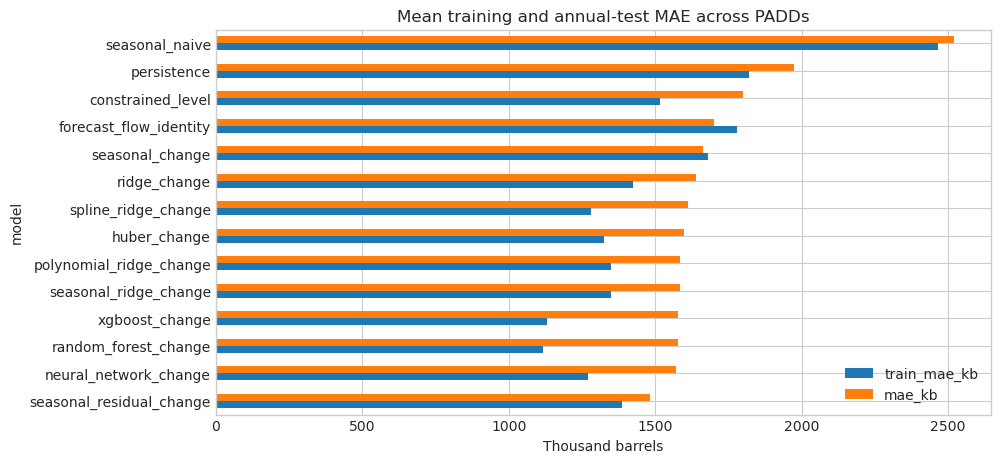

In [27]:
with pd.option_context('display.max_colwidth',None):
    display(selected_parameters)
cv = tables['padd_model_metrics'].query("split == 'cv' and model != 'selected_padd_models'")
display(cv.pivot(index='model', columns='padd', values='mae_kb').style.highlight_min(axis=0))
gaps = folds.groupby('model')[['train_mae_kb','mae_kb']].mean().sort_values('mae_kb')
# Subtract in-sample MAE from validation MAE; positive gaps mean worse
# performance on later observations than on fitted training observations.
gaps['test_minus_train_kb'] = gaps.mae_kb - gaps.train_mae_kb
display(gaps)
gaps[['train_mae_kb','mae_kb']].plot.barh(figsize=(10,5), title='Mean training and annual-test MAE across PADDs')
plt.xlabel('Thousand barrels'); plt.show()


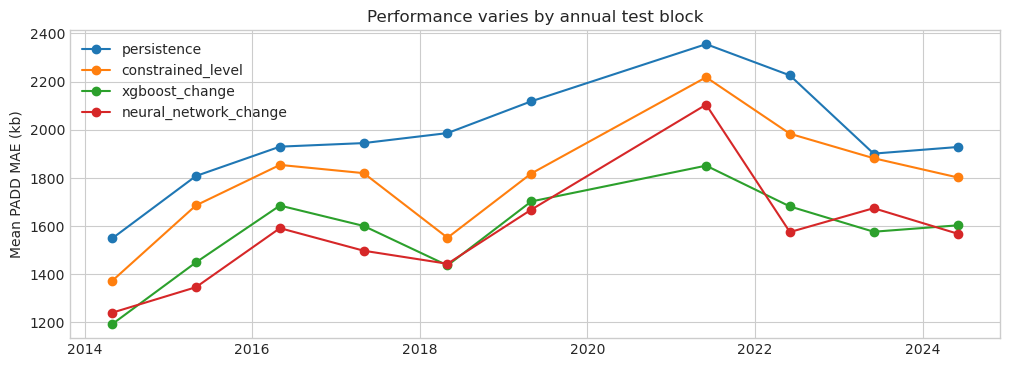

,padd,intercept_kb,stock_lag1,lag_production_kb,lag_demand_kb,lag_imports_kb,lag_exports_kb,lag_net_receipts_kb,lag_adjustments_kb,lag_biofuels_kb
0,1,-982.63,0.59,0.66,0.20,0.24,0.56,0.45,0.45,0.00
1,2,"6,408.44",0.65,0.49,0.32,0.00,0.27,0.39,0.23,0.00
2,3,"30,804.07",0.49,0.29,0.17,0.00,0.00,0.31,0.00,0.00
3,4,"1,238.70",0.70,0.21,0.12,0.00,0.00,0.03,0.00,0.00
4,5,"15,871.19",0.49,0.38,0.41,0.35,0.00,0.47,0.04,0.00


In [28]:
# Group validation errors by test-block endpoint to show regime variation.
# These plotted values average regional MAEs, not errors on national stock sums.
# The coefficient CSV provides a separate view of the constrained model.

fig, ax = plt.subplots(figsize=(12,4))
for name in ['persistence','constrained_level','xgboost_change','neural_network_change']:
    g = folds[folds.model.eq(name)].groupby('test_end').mae_kb.mean()
    ax.plot(pd.to_datetime(g.index), g.values, marker='o', label=name)
ax.set(title='Performance varies by annual test block', ylabel='Mean PADD MAE (kb)')
ax.legend(); plt.show()
display(pd.read_csv(OUTPUT / 'constrained_model_coefficients.csv'))

### Final test: July 2024–June 2026

Compare all one-month methods on the same 24 months. The lowest national MAE determines the current one-month outlook. Because this period was used to choose the method, its MAE describes the historical comparison rather than an independent test of the chosen method.


In [29]:
# Report the current one-month model against persistence on national holdout
# MAE. A positive improvement means lower error. Also identify the best observed
# holdout candidate used for the current one-month outlook.

national_scores = tables['us_model_metrics'].query("split == 'holdout'").sort_values('mae_kb')
display(national_scores)
regional_scores = tables['padd_model_metrics'].query("split == 'holdout'")
regional_scores = regional_scores[regional_scores.model.eq('persistence') | regional_scores.model.eq(metadata['one_month_model'])]
display(regional_scores[['padd','model','mae_kb','rmse_kb','r2']])
selected_mae = national_scores.set_index('model').loc[metadata['one_month_model'],'mae_kb']
naive_mae = national_scores.set_index('model').loc['persistence','mae_kb']
improvement = 100*(1-selected_mae/naive_mae)
best_holdout = national_scores.iloc[0]


,model,split,mae_kb,rmse_kb,r2,n
17,seasonal_change,holdout,"3,426.41","5,092.55",0.85,24
3,forecast_flow_identity,holdout,"3,618.04","5,391.23",0.83,24
21,seasonal_residual_change,holdout,"3,670.53","5,181.12",0.84,24
13,random_forest_change,holdout,"3,783.17","5,546.13",0.82,24
29,xgboost_change,holdout,"4,182.90","5,889.52",0.80,24
25,selected_padd_models,holdout,"4,207.50","5,618.73",0.82,24
7,neural_network_change,holdout,"4,350.48","6,236.63",0.77,24
27,spline_ridge_change,holdout,"4,433.60","5,851.38",0.80,24
5,huber_change,holdout,"4,507.34","6,530.22",0.75,24
23,seasonal_ridge_change,holdout,"4,692.84","6,622.54",0.75,24


,padd,model,mae_kb,rmse_kb,r2
9,1,persistence,"3,407.58","4,606.56",0.01
17,1,seasonal_change,"1,897.99","2,265.42",0.76
39,2,persistence,"3,016.88","3,877.04",0.45
47,2,seasonal_change,"1,584.37","2,039.43",0.85
69,3,persistence,"3,304.79","4,089.56",0.05
77,3,seasonal_change,"2,494.69","3,237.51",0.41
99,4,persistence,467.62,645.18,0.45
107,4,seasonal_change,391.26,547.23,0.60
129,5,persistence,"1,389.08","1,557.95",0.00
137,5,seasonal_change,"1,048.37","1,309.27",0.29


**One-month model:** `seasonal_change` has national MAE of **3,426 kb**, versus **8,469 kb** for unchanged stocks (**59.5% lower**). It also beats the regional model combination, which has MAE of **4,208 kb**. The final period was used to choose `seasonal_change` for the current outlook.


In [30]:
# Summarize eligible dates and check that fitting excludes COVID target months.
# Optional comparison CSVs show earlier refits on matching dates when available.

audit = tables['training_sample_audit']
display(audit.groupby('padd').agg(total_target_months=('training_eligible','size'),
    eligible_stock_training_months=('training_eligible','sum'), evaluation_months=('evaluation_eligible','sum')))
assert not audit.loc[audit.training_eligible, 'month'].between(COVID_START, COVID_END).any()
# Display prior-run comparison files only when available; these optional reports
# are read here and are not recomputed by this cell.
comparison_file = OUTPUT/'refit_comparison.csv'
if comparison_file.exists():
    display(pd.read_csv(comparison_file))
addition_file = OUTPUT/'candidate_addition_comparison.csv'
if addition_file.exists():
    display(pd.read_csv(addition_file))


,total_target_months,eligible_stock_training_months,evaluation_months
padd,,,
1,222,197,209
2,222,197,209
3,222,197,209
4,222,197,209
5,222,197,209


,region,previous_mae_kb,refit_mae_kb,improvement_pct,test_months
0,U.S.,"4,532.35","4,207.50",7.17,24
1,PADD 1,"2,680.72","2,041.47",23.85,24
2,PADD 2,"1,611.69","1,637.79",-1.62,24
3,PADD 3,"2,710.12","2,688.82",0.79,24
4,PADD 4,342.21,362.99,-6.07,24
5,PADD 5,"1,061.09","1,000.05",5.75,24


,candidate_set,period,mae_kb
0,"Original candidates, COVID excluded",cv,"4,276.59"
1,"Original candidates, COVID excluded",holdout,"4,105.54"
2,"Expanded candidates, COVID excluded",cv,"3,938.82"
3,"Expanded candidates, COVID excluded",holdout,"4,207.50"


**Year-ahead comparison on the same forecast dates and origins**


In [31]:
year_comparison = OUTPUT/'year_ahead_refit_comparison.csv'
if year_comparison.exists():
    display(pd.read_csv(year_comparison))


,region,previous_mae_kb,refit_mae_kb,improvement_pct,forecast_observations
0,U.S.,"6,148.94","5,640.90",8.26,24
1,PADD 1,"3,807.25","3,536.11",7.12,24
2,PADD 2,"1,962.53","1,826.36",6.94,24
3,PADD 3,"3,315.85","2,847.06",14.14,24
4,PADD 4,512.41,688.47,-34.36,24
5,PADD 5,"1,742.95","1,645.68",5.58,24


### Regional results

Compare `seasonal_change` with unchanged stocks in each PADD. Positive improvement indicates lower MAE; positive bias indicates stocks were overestimated. U.S. errors are calculated after summing regional forecasts.


,PADD,Average error (kb),Error / average stocks (%),Improvement over unchanged stocks (%),Average bias (kb),Worst month,Largest miss (kb)
0,1,"1,897.99",3.21,44.30,-189.10,2026-01-01,"4,842.40"
1,2,"1,584.37",3.18,47.48,-6.23,2026-04-01,"6,151.00"
2,3,"2,494.69",2.96,24.51,442.43,2026-04-01,"8,809.50"
3,4,391.26,5.03,16.33,51.89,2026-04-01,"1,459.75"
4,5,"1,048.37",3.60,24.53,176.21,2025-11-01,"2,951.40"


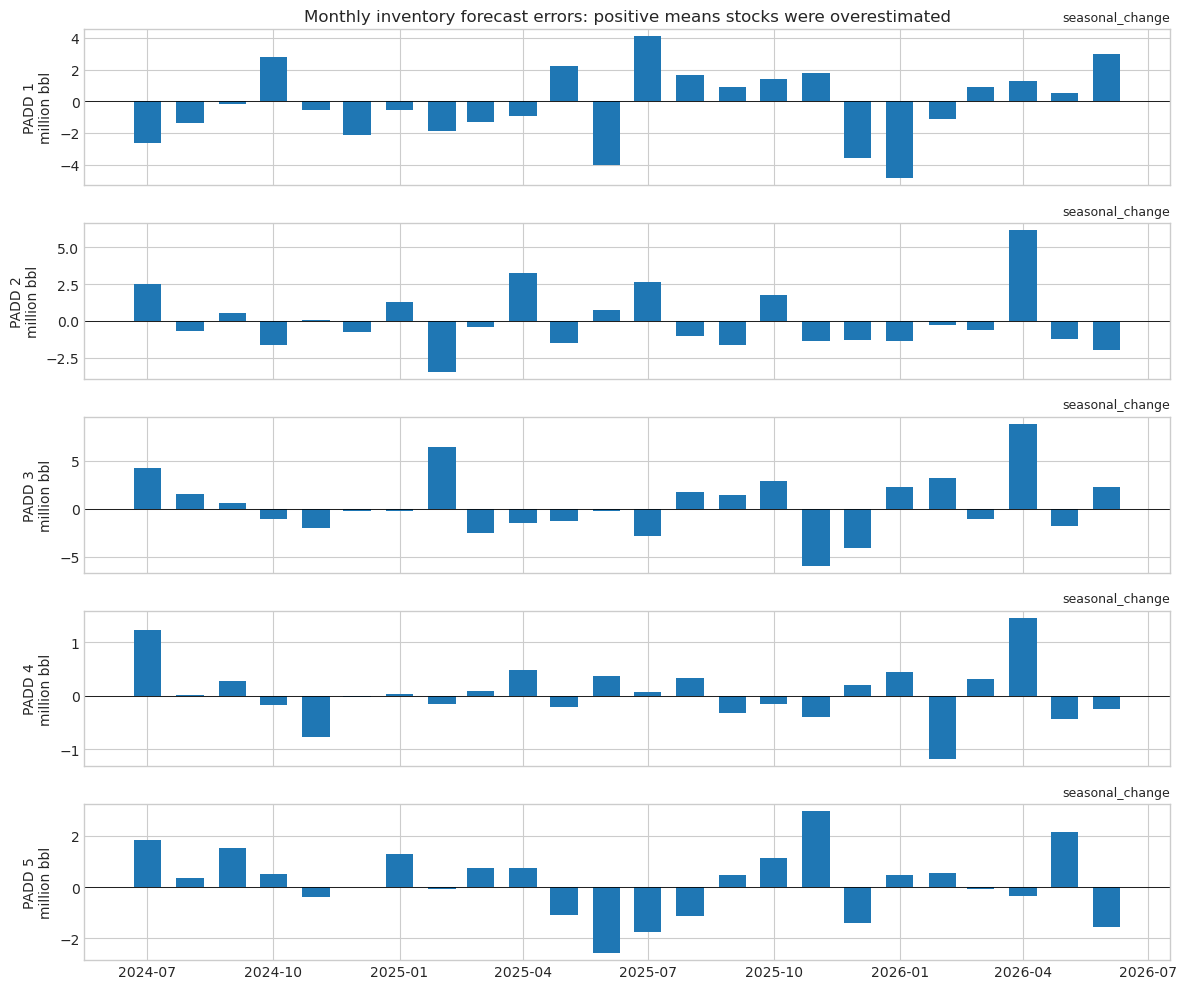

In [32]:
# Compare regional selected-model errors with unchanged stocks on the same
# holdout dates. Normalize MAE by average actual stocks to compare PADD sizes;
# positive percentage improvement means lower error than the benchmark.

# Compare like-for-like regional errors on the same final 24 months.
regional_test = tables['padd_predictions'].query("split == 'holdout'")
regional_selected = regional_test[regional_test.model.eq(metadata['one_month_model'])]
rows = []
for padd, g in regional_selected.groupby('padd'):
    baseline = regional_test[regional_test.padd.eq(padd) & regional_test.model.eq('persistence')]
    # Align selected and persistence forecasts on the same month within this PADD.
    # Validate unique matches so benchmark improvement is a like-for-like comparison.
    paired = g.merge(baseline[['month','predicted_kb']], on='month', suffixes=('', '_unchanged'), validate='one_to_one')
    # Positive signed error means overestimated stocks; absolute error measures
    # miss size, while mean signed error below measures systematic bias.
    error = paired.predicted_kb - paired.actual_kb
    baseline_mae = (paired.predicted_kb_unchanged - paired.actual_kb).abs().mean()
    # Keep the row label of the largest absolute miss to retrieve its calendar month.
    worst = error.abs().idxmax()
    rows.append({'PADD': padd, 'Average error (kb)': error.abs().mean(),
        'Error / average stocks (%)': 100 * error.abs().mean() / paired.actual_kb.mean(),
        'Improvement over unchanged stocks (%)': 100 * (1 - error.abs().mean() / baseline_mae),
        'Average bias (kb)': error.mean(), 'Worst month': paired.loc[worst, 'month'],
        'Largest miss (kb)': error.abs().max()})
regional_review = pd.DataFrame(rows)
display(regional_review)
# Persist regional diagnostics; charts convert kb to million barrels by /1000.
regional_review.to_csv(OUTPUT/'regional_error_review.csv', index=False)
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, (padd, g) in zip(axes, regional_selected.groupby('padd')):
    ax.bar(g.month, (g.predicted_kb-g.actual_kb)/1000, width=20)
    ax.axhline(0, color='black', linewidth=.6)
    ax.set_ylabel(f'PADD {padd}\nmillion bbl')
    ax.set_title(metadata['one_month_model'], fontsize=9, loc='right')
axes[0].set_title('Monthly inventory forecast errors: positive means stocks were overestimated')
plt.tight_layout(); plt.show()

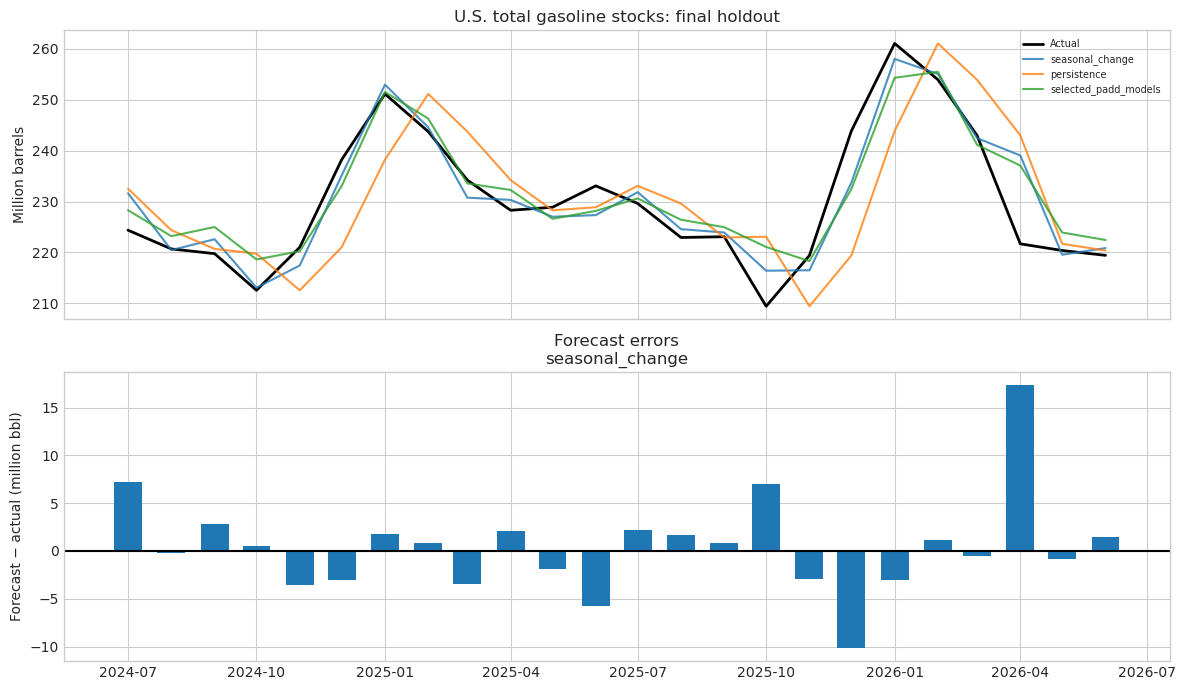

In [33]:
# Use one model's actual column to plot national stocks once, then overlay
# candidate forecasts and signed selected-model errors. Divide kb by 1000
# for million-barrel axes; a positive error bar means excess predicted stocks.

predictions = tables['us_predictions']
holdout = predictions[predictions.split.eq('holdout')]
fig, axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
actual = holdout[holdout.model.eq(metadata['one_month_model'])]
axes[0].plot(actual.month,actual.actual_kb/1000,color='black',label='Actual',linewidth=2)
for name in [metadata['one_month_model'],'persistence','selected_padd_models']:
    g = holdout[holdout.model.eq(name)]
    label = metadata['one_month_model_label'] if name == metadata['one_month_model'] else name
    axes[0].plot(g.month,g.predicted_kb/1000,label=label,alpha=.8)
axes[0].set(ylabel='Million barrels',title='U.S. total gasoline stocks: final holdout'); axes[0].legend(fontsize=7)
axes[1].bar(actual.month,(actual.predicted_kb-actual.actual_kb)/1000,width=20)
axes[1].axhline(0,color='black'); axes[1].set(ylabel='Forecast − actual (million bbl)',title=f"Forecast errors\n{metadata['one_month_model_label']}")
plt.tight_layout(); plt.show()

### Twelve-month performance

Evaluate two separate annual paths without updating forecasts with actual stocks. The development-selected `xgboost_change` model is compared with unchanged stocks and seasonal benchmarks. The same-month-last-year benchmark has the lowest national MAE among those tested and is used for the current twelve-month outlook.


,model,mae_kb,rmse_kb,r2,n
0,xgboost_change,"6,148.45","7,488.24",0.57,72
1,huber_change,"6,471.91","8,255.01",0.48,72
2,random_forest_change,"6,528.86","7,956.32",0.52,72
3,neural_network_change,"6,670.69","8,346.93",0.47,72
4,seasonal_residual_change,"6,879.57","8,300.21",0.47,72
5,seasonal_ridge_change,"7,017.09","8,832.59",0.41,72
6,constrained_level,"7,161.71","8,701.72",0.42,72
7,spline_ridge_change,"7,621.95","9,214.59",0.35,72
8,seasonal_naive,"7,754.90","9,720.72",0.28,72
9,polynomial_ridge_change,"7,799.44","9,643.16",0.29,72


Development-selected year-ahead model: xgboost_change
Current twelve-month outlook model: seasonal_naive


,model,mae_kb,rmse_kb,r2,n
0,persistence,"11,576.96","13,390.48",-0.04,24
1,seasonal_change,"6,446.63","7,435.52",0.68,24
2,seasonal_naive,"4,773.00","5,920.95",0.80,24
3,xgboost_change,"5,640.90","6,821.24",0.73,24


,padd,model,mae_kb,rmse_kb,r2,n
0,1,persistence,"5,579.54","6,392.88",-0.90,24
1,1,seasonal_change,"4,893.18","5,632.27",-0.48,24
2,1,seasonal_naive,"2,636.17","3,171.38",0.53,24
3,1,xgboost_change,"3,536.11","4,348.15",0.12,24
4,2,persistence,"4,113.62","5,451.28",-0.09,24
5,2,seasonal_change,"1,500.43","1,788.21",0.88,24
6,2,seasonal_naive,"1,531.96","1,949.99",0.86,24
7,2,xgboost_change,"1,826.36","2,131.49",0.83,24
8,3,persistence,"3,973.50","4,711.83",-0.26,24
9,3,seasonal_change,"4,309.68","4,795.94",-0.30,24


,padd,mae_kb,rmse_kb,r2,n
0,1,"2,636.17","3,171.38",0.53,24
1,2,"1,531.96","1,949.99",0.86,24
2,3,"3,214.25","3,672.90",0.24,24
3,4,375.04,428.63,0.76,24
4,5,"1,819.75","2,011.59",-0.67,24


,horizon,mae_kb,rmse_kb,r2,n
0,1,"4,375.00","4,460.66",-1.89,2
1,2,"1,894.50","1,926.29",-1.95,2
2,3,"5,716.50","6,198.51",-12.94,2
3,4,"4,640.50","4,881.39",-8.75,2
4,5,"1,058.00","1,194.27",-1.20,2
5,6,"4,068.50","4,360.38",-1.39,2
6,7,"5,437.50","7,038.67",-1.02,2
7,8,"6,618.50","7,523.02",-1.18,2
8,9,"4,731.50","6,228.45",-1.01,2
9,10,"6,002.50","6,030.70",-2.35,2


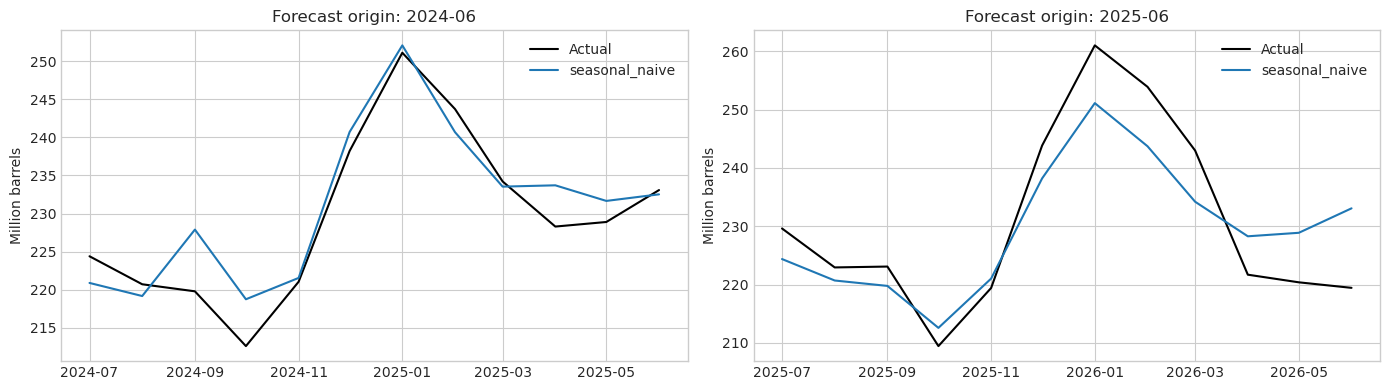

In [34]:
# Compare the development-selected year-ahead family with recursive benchmarks,
# scoring after national aggregation. Each horizon has only two
# path observations here; the plots show those two forecast origins separately.

display(tables['year_ahead_model_cv_metrics'])
print('Development-selected year-ahead model:', metadata['development_year_ahead_model'])
print('Current twelve-month outlook model:', metadata['year_ahead_model'])
bench = tables['recursive_benchmark_predictions']
paths = bench
us_paths = aggregate(paths, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
display(metric_table(us_paths,['model']))
display(metric_table(paths,['padd','model']))

recursive = tables['us_recursive_holdout_predictions']
display(tables['recursive_holdout_metrics'])
display(tables['us_recursive_horizon_metrics'])
fig, axes = plt.subplots(1,2,figsize=(14,4))
for (origin,g),ax in zip(recursive.groupby('origin_month'),axes):
    ax.plot(g.month,g.actual_kb/1000,label='Actual',color='black')
    ax.plot(g.month,g.predicted_kb/1000,label=metadata['year_ahead_model'])
    ax.set(title=f'Forecast origin: {origin:%Y-%m}',ylabel='Million barrels'); ax.legend()
plt.tight_layout(); plt.show()

### Twelve-month outlook

Project supply, disposition, and total gasoline stocks from the latest observed month. The one-month outlook uses `seasonal_change`; the twelve-month path uses `seasonal_naive` (the same month last year).


,month,production_kb,imports_kb,demand_kb,exports_kb,adjustments_kb,balance_kb,stock_kb,identity_stock_unclipped_kb,model_reconciliation_kb
0,2026-07-01,"283,420.44","20,924.24","282,345.05","26,409.35","1,221.09","-2,984.03","229,625.00","216,456.97","13,168.03"
1,2026-08-01,"284,033.04","21,119.64","285,183.65","26,615.95","1,116.49","-5,316.83","222,943.00","211,140.14","-1,365.17"
2,2026-09-01,"274,602.14","18,129.34","267,452.30","25,445.17",697.01,725.71,"223,093.00","211,865.85",-575.71
3,2026-10-01,"281,101.44","14,102.44","278,402.05","26,921.15","2,089.89","-7,833.03","209,448.00","204,032.82","-5,811.97"
4,2026-11-01,"287,758.14","14,597.34","265,572.30","31,358.97","1,659.81","7,257.71","219,418.00","211,290.53","2,712.29"
5,2026-12-01,"301,164.24","17,356.41","271,929.45","33,203.75","1,688.49","15,230.74","243,854.00","226,521.27","9,205.26"
6,2027-01-01,"284,511.24","12,709.64","256,063.05","27,418.55","1,437.29","15,323.57","261,035.00","241,844.84","1,857.43"
7,2027-02-01,"246,669.32","12,753.17","242,057.78","23,186.43",915.95,"-4,762.51","253,923.00","237,082.33","-2,349.49"
8,2027-03-01,"274,655.04","15,028.24","276,444.45","26,285.95","1,564.09","-11,306.43","242,995.00","225,775.90",378.43
9,2027-04-01,"263,685.74","19,544.14","267,680.10","23,653.77",550.81,"-7,368.49","221,699.00","218,407.42","-13,927.51"


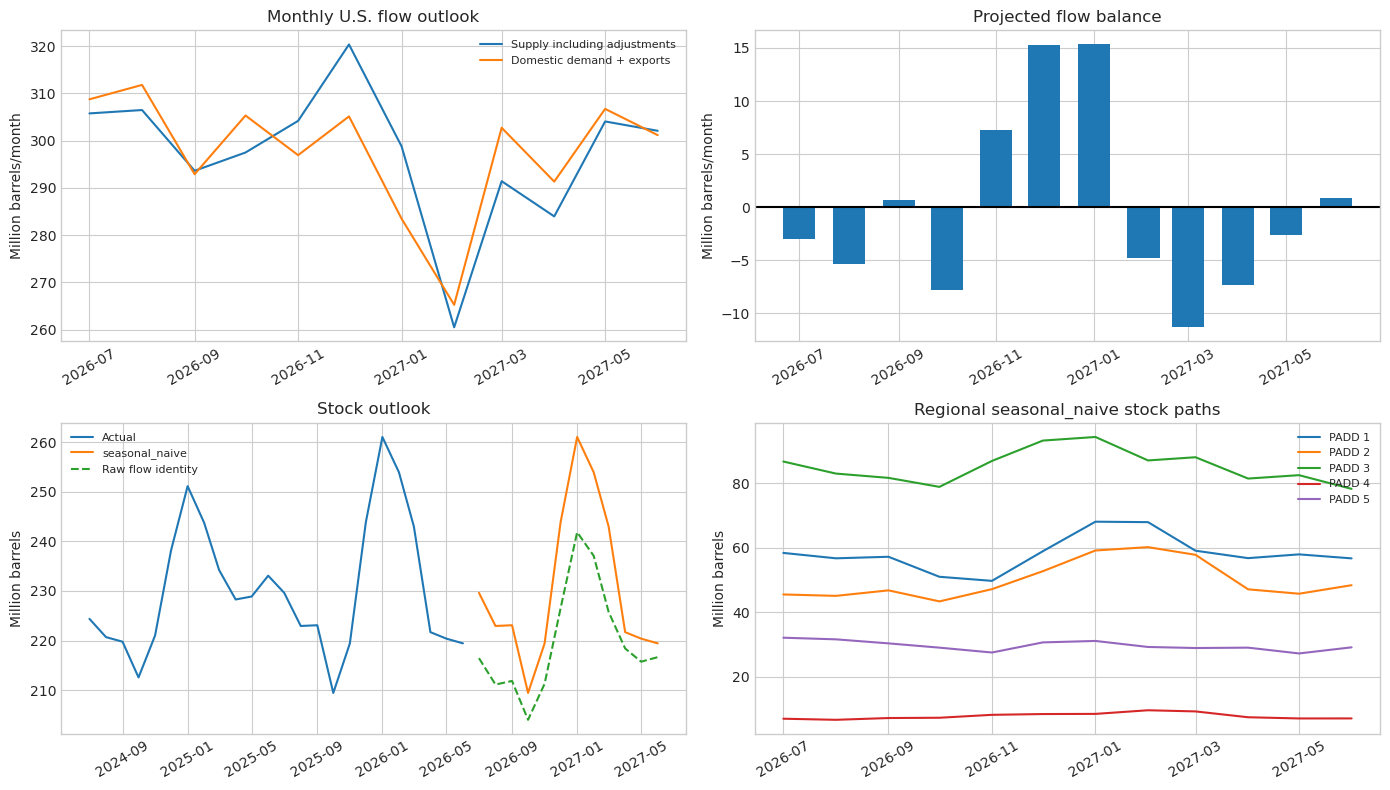

In [35]:
# Plot the conditional 12-month flow and stock outlook. The statistical stock
# path and raw accumulated flow identity need not coincide: reconciliation
# measures predicted stock change minus forecast net supply, not an observed flow.

outlook = tables['us_forecast_12m']
display(outlook[['month','production_kb','imports_kb','demand_kb','exports_kb','adjustments_kb',
                 'balance_kb','stock_kb','identity_stock_unclipped_kb','model_reconciliation_kb']])
fig, axes = plt.subplots(2,2,figsize=(14,8))
for c,label in [('supply_kb','Supply including adjustments'),('total_demand_kb','Domestic demand + exports')]:
    axes[0,0].plot(outlook.month,outlook[c]/1000,label=label)
axes[0,0].set(title='Monthly U.S. flow outlook',ylabel='Million barrels/month'); axes[0,0].legend(fontsize=8)
axes[0,1].bar(outlook.month,outlook.balance_kb/1000,width=20)
axes[0,1].axhline(0,color='black'); axes[0,1].set(title='Projected flow balance',ylabel='Million barrels/month')
recent = tables['us_monthly_model'].tail(24)
axes[1,0].plot(recent.month,recent.stock_kb/1000,label='Actual')
axes[1,0].plot(outlook.month,outlook.stock_kb/1000,label=metadata['year_ahead_model'])
axes[1,0].plot(outlook.month,outlook.identity_stock_unclipped_kb/1000,label='Raw flow identity',linestyle='--')
axes[1,0].set(title='Stock outlook',ylabel='Million barrels'); axes[1,0].legend(fontsize=8)
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1,1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[1,1].set(title=f"Regional {metadata['year_ahead_model']} stock paths",ylabel='Million barrels'); axes[1,1].legend(fontsize=8)
for ax in axes.flat: ax.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()

### One-month national results


In [36]:
# Summarize national forecasts on matched months and origins.
one = tables['us_predictions'].query("split == 'holdout'").copy()
one_name = metadata['one_month_model']
long_name = metadata['year_ahead_model']
long = us_paths.copy()
history_stocks = tables['us_monthly_model'].set_index('month').stock_kb
base = long[long.model.eq(long_name)].copy()
assert not base.duplicated(['origin_month', 'month']).any()
year_ago = base.copy()
lag_dates = year_ago.month - pd.DateOffset(years=1)
assert (lag_dates <= year_ago.origin_month).all()
year_ago['predicted_kb'] = history_stocks.reindex(lag_dates).to_numpy()
assert year_ago.predicted_kb.notna().all()
year_ago['model'] = 'seasonal_naive'
long = pd.concat([long[~long.model.eq('seasonal_naive')], year_ago], ignore_index=True)

def summary_table(frame):
    rows = []
    reference = frame[frame.model.eq('persistence')].set_index(['origin_month', 'month'])
    for name, group in frame.groupby('model'):
        aligned = group.set_index(['origin_month', 'month']).sort_index()
        pd.testing.assert_index_equal(aligned.index, reference.sort_index().index)
        np.testing.assert_allclose(aligned.actual_kb, reference.sort_index().actual_kb)
        rows.append(dict(model=name, **score(group.actual_kb, group.predicted_kb),
                         bias_kb=(group.predicted_kb-group.actual_kb).mean()))
    result = pd.DataFrame(rows).set_index('model').sort_values('mae_kb')
    for benchmark, label in [('persistence','MAE improvement vs persistence (%)'),
                             ('seasonal_naive','MAE improvement vs year ago (%)')]:
        result[label] = 100*(1-result.mae_kb/result.loc[benchmark,'mae_kb'])
    return result

short_scores, long_scores = summary_table(one), summary_table(long)
report = short_scores.copy()
for column in ['mae_kb','rmse_kb','bias_kb']:
    report[column] /= 1000
display(report.rename(columns={'mae_kb':'MAE (million bbl)', 'rmse_kb':'RMSE (million bbl)',
    'bias_kb':'Bias (million bbl)', 'r2':'R²', 'n':'Forecast observations'}))


,MAE (million bbl),RMSE (million bbl),R²,Forecast observations,Bias (million bbl),MAE improvement vs persistence (%),MAE improvement vs year ago (%)
model,,,,,,,
seasonal_change,3.43,5.09,0.85,24,0.48,59.54,28.21
forecast_flow_identity,3.62,5.39,0.83,24,0.93,57.28,24.20
seasonal_residual_change,3.67,5.18,0.84,24,0.88,56.66,23.10
random_forest_change,3.78,5.55,0.82,24,0.84,55.33,20.74
xgboost_change,4.18,5.89,0.80,24,0.81,50.61,12.36
selected_padd_models,4.21,5.62,0.82,24,1.30,50.32,11.85
neural_network_change,4.35,6.24,0.77,24,0.73,48.63,8.85
spline_ridge_change,4.43,5.85,0.80,24,0.76,47.65,7.11
huber_change,4.51,6.53,0.75,24,-0.49,46.78,5.57


### Twelve-month path results


In [37]:
report = long_scores.copy()
for column in ['mae_kb','rmse_kb','bias_kb']:
    report[column] /= 1000
display(report.rename(columns={'mae_kb':'MAE (million bbl)', 'rmse_kb':'RMSE (million bbl)',
    'bias_kb':'Bias (million bbl)', 'r2':'R²', 'n':'Forecast observations'}))


,MAE (million bbl),RMSE (million bbl),R²,Forecast observations,Bias (million bbl),MAE improvement vs persistence (%),MAE improvement vs year ago (%)
model,,,,,,,
seasonal_naive,4.77,5.92,0.80,24,0.22,58.77,0.00
xgboost_change,5.64,6.82,0.73,24,0.95,51.27,-18.18
seasonal_change,6.45,7.44,0.68,24,5.14,44.31,-35.06
persistence,11.58,13.39,-0.04,24,2.64,0.00,-142.55


The lowest observed one-month MAE belongs to `seasonal_change` at **3.43 million barrels**. It is used for the current one-month outlook after reviewing the final period.

**One-month method: `seasonal_change`.** MAE is **3.43 million barrels**, RMSE is **5.09 million barrels**, and R² is **0.85**. MAE is **59.5% lower** than unchanged stocks and **28.2% lower** than the same month last year. This final-period score was used to choose the method.

`xgboost_change` had the lowest national MAE across six development-year paths. The same-month-last-year benchmark had the lowest MAE among methods tested on the two final-period paths and is used for the current twelve-month outlook.

**Twelve-month method: `seasonal_naive`.** MAE is **4.77 million barrels**, RMSE is **5.92 million barrels**, and R² is **0.80** across two paths. MAE is **58.8% lower** than unchanged stocks and **15.4% lower** than `xgboost_change`.

The xgboost method probably overfit on the training data as it performs worse than `seasonal_naive`.

In [38]:
# Compare the development runner-up with the selected seasonal benchmark on
# the same two complete final-period paths.
development_scores = tables['year_ahead_model_cv_metrics'].sort_values(['mae_kb','model'])
runner_name = development_scores.iloc[1].model
parameter_rows = tables['best_parameters'].set_index(['padd','model'])
runner_paths = []
for offset in [24, 12]:
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    states = {}
    for padd in PADD_NAMES:
        history = panel[panel.padd.eq(padd)].reset_index(drop=True)
        training = supervised(history)
        training = training[training.month.le(cutoff)]
        params = json.loads(parameter_rows.loc[(padd, runner_name), 'params'])
        model, warning = fit(runner_name, training, params)
        states[padd] = {'name':runner_name, 'estimator':model}
    regional_path, _ = forecast(panel[panel.month.le(cutoff)], states)
    regional_path = regional_path[['padd','month','origin_month','horizon','stock_kb']]
    regional_path = regional_path.rename(columns={'stock_kb':'predicted_kb'})
    regional_path = regional_path.merge(panel[['padd','month','stock_kb']],
        on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
    runner_paths.append(regional_path)
runner_us = aggregate(pd.concat(runner_paths, ignore_index=True),
    ['origin_month','month','horizon'], ['actual_kb','predicted_kb']).assign(model=runner_name)
seasonal_us = tables['us_recursive_holdout_predictions'].copy()
assert metadata['year_ahead_model'] == 'seasonal_naive'
seasonal_us['model'] = 'seasonal_naive'
comparison = pd.concat([runner_us, seasonal_us[runner_us.columns]], ignore_index=True)
for name, group in comparison.groupby('model'):
    aligned = group.set_index(['origin_month','month']).sort_index()
    reference = seasonal_us.set_index(['origin_month','month']).sort_index()
    pd.testing.assert_index_equal(aligned.index, reference.index)
    np.testing.assert_allclose(aligned.actual_kb, reference.actual_kb)
comparison_scores = metric_table(comparison, ['model']).sort_values('mae_kb')
comparison_by_origin = metric_table(comparison, ['origin_month','model']).sort_values(['origin_month','mae_kb'])
for table in (comparison_scores, comparison_by_origin):
    report = table.copy()
    report['mae_kb'] /= 1000
    report['rmse_kb'] /= 1000
    display(report.rename(columns={'mae_kb':'MAE (million bbl)',
        'rmse_kb':'RMSE (million bbl)', 'r2':'R²', 'n':'Forecast observations'}))


,model,MAE (million bbl),RMSE (million bbl),R²,Forecast observations
1,seasonal_naive,4.77,5.92,0.80,24
0,huber_change,6.91,9.15,0.51,24


,origin_month,model,MAE (million bbl),RMSE (million bbl),R²,Forecast observations
1,2024-06-01,seasonal_naive,2.98,3.80,0.87,12
0,2024-06-01,huber_change,5.96,7.76,0.46,12
3,2025-06-01,seasonal_naive,6.57,7.46,0.76,12
2,2025-06-01,huber_change,7.86,10.36,0.54,12


### Development runner-up versus the seasonal benchmark

`huber_change` had the second-lowest national MAE on the six development paths: **6.47 million barrels**, compared with **6.15 million** for `xgboost_change`.

On the same two final-period paths, `huber_change` has MAE of **6.91 million barrels** and `seasonal_naive` has MAE of **4.77 million barrels**. The runner-up's MAE is **44.7% higher**. `seasonal_naive` has lower MAE on each annual path.

The `seasonal_naive` is actually a pretty well performing model by itself. Using more complex models seems to not help at all as they both perform much worse.


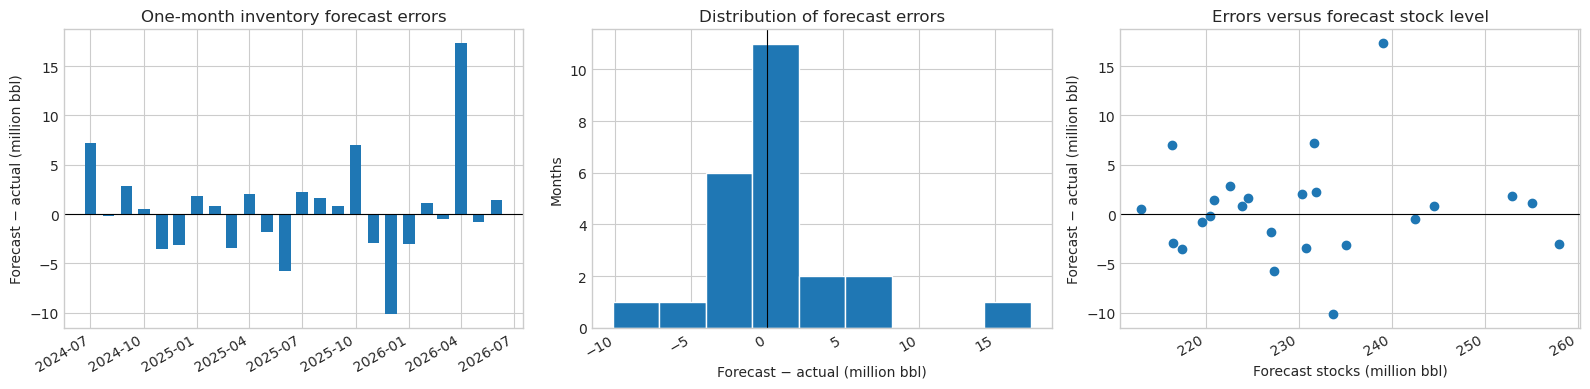

In [39]:
selected = one[one.model.eq(one_name)].sort_values('month').copy()
selected['error'] = (selected.predicted_kb-selected.actual_kb)/1000
fig, axes = plt.subplots(1,3,figsize=(16,4))
axes[0].bar(selected.month,selected.error,width=20)
axes[0].set(title='One-month inventory forecast errors',ylabel='Forecast − actual (million bbl)')
axes[1].hist(selected.error,bins=9,edgecolor='white')
axes[1].set(title='Distribution of forecast errors',xlabel='Forecast − actual (million bbl)',ylabel='Months')
axes[2].scatter(selected.predicted_kb/1000,selected.error)
axes[2].set(title='Errors versus forecast stock level',xlabel='Forecast stocks (million bbl)',ylabel='Forecast − actual (million bbl)')
for ax in [axes[0],axes[2]]: ax.axhline(0,color='black',linewidth=.8)
axes[1].axvline(0,color='black',linewidth=.8)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()


The one-month `seasonal_change` method has average signed error of **+0.48 million barrels**. Its largest absolute monthly miss is **17.35 million barrels**.


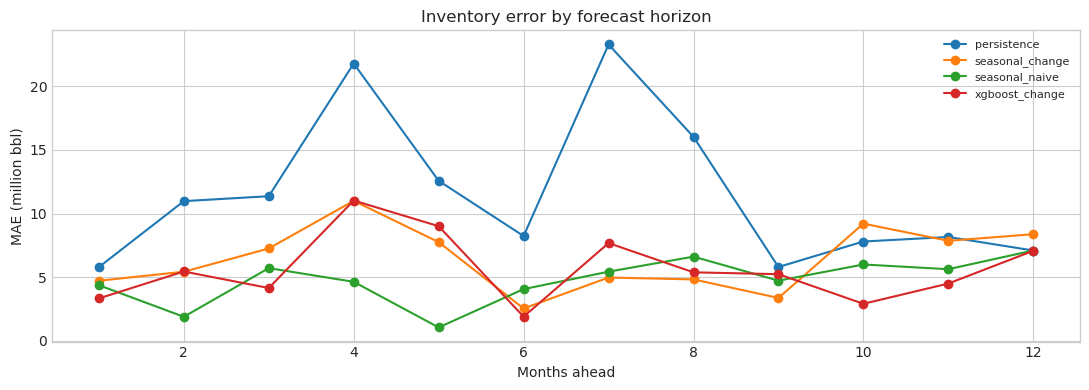

In [40]:
fig, ax = plt.subplots(figsize=(11,4))
for name, group in long.groupby('model'):
    errors = group.assign(error=(group.predicted_kb-group.actual_kb).abs()/1000)
    errors.groupby('horizon').error.mean().plot(ax=ax,marker='o',label=name)
ax.set(title='Inventory error by forecast horizon',xlabel='Months ahead',ylabel='MAE (million bbl)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


**Year-ahead benchmark check:** The same-month-last-year method has **15.4% lower MAE** than `xgboost_change` on the two tested paths.


### Interpretation

Higher refinery and blender production increases gasoline supply. Product supplied and exports reduce stocks, all else equal.

Seasonal changes have the lowest national one-month MAE in the final period. The same-month-last-year benchmark has the lowest MAE among methods tested on two year-ahead paths and is used for the current twelve-month outlook.

The outlook reflects historical relationships and excludes explicit price, outage, and turnaround scenarios.

### Reproduce the results

Run All repeats training and evaluation. Checks cover source data, stock definitions, forecast timing, regional totals, and training dates. See the README to refresh reports from saved results.

In [41]:
# Check the model's stock scope and accounting identities, then perturb the
# last target observation to verify target-month isolation. Finally require
# the national forecast to equal the sum of the five regional forecasts.

np.testing.assert_allclose(panel.stock_kb, panel.finished_stock_kb + panel.blending_stock_kb, atol=1, rtol=0)
np.testing.assert_allclose(panel.production_kb, panel.finished_production_kb-panel.blending_net_inputs_kb)
check_history=panel[panel.padd.eq(1)].iloc[:40].copy()
before=supervised(check_history)
# Perturb the final target month's stocks and flows substantially to test that
# its own inputs cannot see target-month information.
check_history.loc[check_history.index[-1],FLOWS+['stock_kb']]+=100000
changed=supervised(check_history)
# Only target labels may change after perturbing the final observation. All
# predictors, origin dates, and flow-identity forecasts must remain identical.
feature_columns=[c for c in before if c not in ['actual_kb','delta_kb']]
pd.testing.assert_frame_equal(before[feature_columns],changed[feature_columns])
np.testing.assert_allclose(tables['us_forecast_12m'].stock_kb,
    tables['padd_forecast_12m'].groupby('month').stock_kb.sum())
print('Source integrity, stock scope, target-month isolation, and aggregation checks passed.')

Source integrity, stock scope, target-month isolation, and aggregation checks passed.


In [42]:
# Inspect run configuration and saved artifacts, and validate output shape: no
# duplicate forecasts, all five PADDs each month, and a full 12-month outlook.

display(pd.Series(metadata, name='Configuration'))
print('Saved result files:')
for path in sorted(OUTPUT.iterdir()):
    print(path.name)
assert not tables['padd_predictions'].duplicated(['padd','month','model','split']).any()
assert tables['padd_forecast_12m'].groupby('month').padd.nunique().eq(5).all()
assert len(outlook) == 12
print('Notebook checks passed.')

product                         Total motor gasoline: finished motor gasoline ...
covid_exclusion                 {'start': '2020-03-01', 'end': '2021-03-01', '...
stock_units                                         thousand barrels at month end
flow_units                                    thousand barrels per calendar month
equation                        S[t] = S[t-1] + (finished refinery/blender net...
data_start                                                             2007-01-01
data_end                                                               2026-06-01
cv                              10 expanding folds, 12 eligible test months ea...
holdout_start                                                          2024-07-01
forecast_timing                 One month after latest observed EIA month; con...
one_month_models                {'1': 'seasonal_change', '2': 'seasonal_change...
one_month_model                                                   seasonal_change
one_month_model_

Saved result files:
all_fitted_models.joblib
best_parameters.csv
candidate_addition_comparison.csv
candidate_models.json
constrained_model_coefficients.csv
fit_warnings.csv
fitted_horizon_models.joblib
fitted_models.joblib
fold_metrics.csv
grid_search_results.csv
historical_balance_exceptions.csv
latest_forecast.csv
model_metadata.json
padd_forecast_12m.csv
padd_model_metrics.csv
padd_monthly_model.csv
padd_predictions.csv
recursive_benchmark_predictions.csv
recursive_cv_predictions.csv
recursive_holdout_metrics.csv
recursive_holdout_predictions.csv
refit_comparison.csv
regional_error_review.csv
selected_models.csv
training_sample_audit.csv
us_forecast_12m.csv
us_model_metrics.csv
us_monthly_model.csv
us_predictions.csv
us_recursive_cv_predictions.csv
us_recursive_holdout_predictions.csv
us_recursive_horizon_metrics.csv
year_ahead_model_cv_metrics.csv
year_ahead_refit_comparison.csv
Notebook checks passed.
